# AIMLC ZG521 — Conversational AI · Group Assignment 1
## Problem Statement 2 — Study of Embedding Models and Approximate Nearest Neighbor Search: Semantic Quality vs Search Efficiency

**Group 129**






## Student Details

| Name | BITS ID | Email |
|---|---|---|
| Pushadapu Sanjay Kumar | 2025ae05898 | 2025ae05898@wilp.bits-pilani.ac.in |
| B Devchandraaj | 2025ae05469 | 2025ae05469@wilp.bits-pilani.ac.in |
| Gourob Nandi | 2025ae05503 | 2025ae05503@wilp.bits-pilani.ac.in |
| Anirudh Anand | 2025ae05576 | 2025ae05576@wilp.bits-pilani.ac.in |


## Group Contributions

| Student | Contribution area | Specific contribution |
|---|---|---|
| B Devchandraaj | Dataset and embedding | Dataset loading, validation, and embedding generation |
| Pushadapu Sanjay Kumar | Similarity and exact kNN | Metric formulas, normalization analysis, and exact retrieval |
| Gourob Nandi | HNSW and IVF | FAISS index construction and ANN parameter sweeps |
| Anirudh Anand | Evaluation and reporting | Metrics, visualizations, qualitative examples, and report preparation |

## Architecture and Workflow

The workflow uses the same corpus, query set, identifiers, normalized vectors, and qrels for every comparison. Documents are encoded offline; queries are encoded at search time. Exact cosine kNN provides an exhaustive reference baseline, while HNSW and IVF approximate the same inner-product search space. Retrieval quality is measured with qrels and efficiency is measured using latency, speedup, and candidate-vector estimates.

```text
SciFact corpus + queries + qrels
              |
      Validate and align IDs
              |
   +----------+-----------+
   |                      |
Encoder 1              Encoder 2
DistilBERT             BGE-large
   |                      |
Normalized vectors   Normalized vectors
   |                      |
   +----------+-----------+
              |
 Exact kNN / HNSW / IVF
              |
 Recall@5, latency, speedup,
 candidate estimates, examples
              |
       Final recommendation
```

Figure 1. Experimental workflow for the embedding and ANN comparison.


## Executive Summary (one page)

**Objective.** Compare two encoder embedding models and two approximate-nearest-neighbour (ANN) indexes on a real retrieval task, trading off **semantic quality vs. search efficiency**, and recommend a production configuration — every claim backed by executed results.

**Dataset.** SciFact (BEIR): **5,183** document passages, **300** queries, each with relevance judgments (qrels). Clears the 1,000-passage / 50-query minimums.

**Models.** `distilbert-base-uncased` (768-dim, mean pooling, general-purpose) vs. `BAAI/bge-large-en-v1.5` (1024-dim, [CLS] pooling, retrieval-tuned). A deliberately contrasting pair.

**Key results (executed).**

| Finding | Result |
|---|---|
| Best embedding model (exact Recall@5) | **BGE-large 0.780** vs DistilBERT 0.108 (~7x higher) |
| Most appropriate metric | **Cosine** — identical ranking to dot/L2 on unit-normalized vectors; scale-invariant. Normalization changes dot-vs-cosine ranking for 4/5 sampled queries (vectors not unit-length) but not for BGE (already unit-length) |
| Best ANN trade-off | **HNSW efSearch=16** — Recall@5 = 0.773: fastest config clearing the Recall@5 >= 0.75 bar (measured speedup in Task 6) |
| Fastest ANN | IVF nprobe=1 — fastest overall but Recall@5 = 0.502 — rejected by the quality bar |
| Model disagreement (Task 7) | Mean Top-5 set overlap ~ 0.11 — the two models genuinely retrieve different documents |

**Recommendation.** Embed with **BGE-large (unit-normalized)** and serve **HNSW efSearch=16**; where RAM is the binding constraint use **IVF nprobe=20** tuned to meet the recall bar. Deploy by encoding documents offline, normalizing, indexing, and applying the same encoder + normalization to queries at search time.

---


## Tools and Libraries Used

- **Python 3.14.5** (recorded execution environment)
- `datasets` (Hugging Face) — loading the BEIR-format retrieval dataset
- `pandas`, `numpy` — data handling
- `sentence-transformers` — encoder embedding models (Task 2 onward)
- `faiss-cpu` — HNSW / IVF ANN indexes (Task 5 onward)
- `matplotlib` — plots (Task 6 onward)

Install all of the above with: `pip install -r requirements.txt` (see `ass-1/requirements.txt`).

---
## Executive Summary

This assignment investigates two core questions in semantic retrieval: **which embedding model produces better representations for scientific claim retrieval**, and **how much search speed can be gained through approximate nearest-neighbor (ANN) indexing without sacrificing retrieval quality**.

**Dataset:** SciFact (BEIR benchmark) — 5,183 biomedical corpus passages, 300 labelled queries, binary relevance judgments.

**Models compared:**
- `distilbert-base-uncased` — general-purpose, mean-pooled, 768-dim, not retrieval-tuned.
- `BAAI/bge-large-en-v1.5` — contrastively fine-tuned for retrieval, CLS-pooled, 1024-dim.

**Key findings:**

| Question | Answer | Evidence |
|---|---|---|
| Best embedding model | **BGE-large** | Recall@5 = 0.780 vs 0.108 for DistilBERT (7x higher) |
| Best similarity metric | **Cosine** | Scale-invariant; equivalent to dot product and L2 on unit-norm vectors (verified Task 3) |
| Best ANN trade-off | **HNSW `efSearch=16`** | Recall@5 = 0.773, fastest tested configuration meeting the 0.75 quality bar (measured speedup in Task 6) |
| Fastest ANN | **IVF `nprobe=1`** | Recall@5 = 0.502 (fastest overall); rejected by the quality bar |
| Resource-constrained option | **IVF** (possibly lower graph-related overhead; total footprint not measured) | HNSW graph overhead may exceed IVF's graph-free structure; use IVF `nprobe=20` to meet the recall target and verify memory on target hardware |
| Main limitation | Small corpus | 5k-doc corpus limits ANN speedup benefit; binary/incomplete qrels |
| Production deployment | Offline encode → normalize → FAISS index → query API | Rebuild index on corpus changes |

**Recommendation:** Embed with BGE-large (unit-normalized vectors) and serve an HNSW index at `efSearch=16`. This configuration achieves Recall@5 = 0.773, several times faster than exact search (exact speedup reported in Task 6), with quality above the 0.75 operational threshold.


## Environment Bootstrap (auto-install)

This cell makes the notebook self-contained: run it first and any missing package from `requirements.txt` is installed automatically into the current kernel. Safe to re-run — already-installed packages are skipped.

In [1]:
# AUTO-INSTALL: install any required package that is missing in this kernel.
# Run this cell FIRST when opening the notebook standalone (e.g. in a virtual lab).
import importlib.util, subprocess, sys

# (import name that Python actually uses)  ->  (pip package name to install)
REQUIRED = {
    "datasets": "datasets",
    "pandas": "pandas",
    "numpy": "numpy",
    "sentence_transformers": "sentence-transformers",
    "huggingface_hub": "huggingface-hub",
    "faiss": "faiss-cpu",
    "matplotlib": "matplotlib",
    "truststore": "truststore",
}

missing = [pip_name for import_name, pip_name in REQUIRED.items()
           if importlib.util.find_spec(import_name) is None]

if missing:
    print("Installing missing packages:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("Done. If imports below fail, restart the kernel and run all cells.")
else:
    print("All required packages are already installed.")


All required packages are already installed.


In [2]:
# Purpose: environment setup. Trusts the OS cert store and routes
# through the corporate proxy (fixes SSL errors on office/lab networks), then
# imports libraries and defines two reuse helpers used later: resolve_model()
# (use a local model copy if one exists, else download) and
# load_aligned_embeddings() (load saved embeddings, reordered by id).
import os

# macOS fix: torch and faiss-cpu both bundle their own OpenMP runtime;
# loading both in one process crashes the kernel silently (OMP: Error #15)
# unless this is set before either library is imported.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

try:
    import truststore
    truststore.inject_into_ssl()
except Exception:
    pass  # fine if unavailable -- only needed behind an SSL-inspecting proxy

import urllib.request
_proxy = urllib.request.getproxies().get("https") or urllib.request.getproxies().get("http")
if _proxy:
    os.environ["HTTP_PROXY"] = os.environ["HTTPS_PROXY"] = _proxy
    os.environ["http_proxy"] = os.environ["https_proxy"] = _proxy

import sys, time, json, random
import numpy as np
import pandas as pd

random.seed(129)   # Group 129 -- fixed seed for reproducibility
np.random.seed(129)


def resolve_model(model_name):
    """Return a local model path, downloading it into models/ when needed."""
    os.makedirs("models", exist_ok=True)
    local = os.path.join("models", model_name.split("/")[-1])
    if os.path.isdir(local) and os.path.exists(os.path.join(local, "config.json")):
        print(f"[info] Using cached model: {local}/")
        return local

    try:
        from huggingface_hub import snapshot_download
        print(f"[info] Downloading {model_name} into {local}/ ...")
        snapshot_download(
            repo_id=model_name,
            local_dir=local
        )
        print(f"[info] Model cached in {local}/")
        return local
    except Exception as exc:
        # SentenceTransformer can still use its standard Hugging Face cache.
        print(f"[warning] Could not cache {model_name} locally: {exc!r}")
        print("[info] Falling back to the Hugging Face model ID.")
        return model_name


def load_aligned_embeddings(emb_path, id_path, wanted_ids):
    """Load a saved embedding array, reordered to match wanted_ids (via the
    id file saved alongside it), so row order never has to be assumed."""
    emb = np.load(emb_path)
    if os.path.exists(id_path):
        saved_ids = [str(x) for x in json.load(open(id_path))]
        pos = {sid: i for i, sid in enumerate(saved_ids)}
        emb = emb[[pos[str(w)] for w in wanted_ids]]
    return emb


print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("numpy :", np.__version__)


Python: 3.14.5
pandas: 3.0.5
numpy : 2.5.2


---
# Task 1 — Corpus and Query Dataset Preparation 

**Dataset chosen: `SciFact`** (BEIR benchmark; Thakur et al., 2021 / Wadden et al., 2020) — a publicly available dataset that ships a document corpus, a query set, and query-document relevance labels together, matching this task's requirement exactly. Corpus (~5,183 passages) and queries (~300) both clear the 1,000/50 minimums.


In [3]:
# Purpose: load SciFact (corpus/queries/qrels). Uses the local
# data/raw/ copy if present (no network needed -- works behind a proxy that
# blocks the Hub); otherwise downloads from Hugging Face. Queries are then
# filtered to only those with a relevance judgment.
import os
import pandas as pd

RAW_FILES = ("corpus.jsonl", "queries.jsonl", "qrels.tsv")


def _find_data_raw():
    """First data/raw directory (checked relative to cwd, then one level up)
    that already contains all three raw files, or None."""
    for base in (os.path.join("data", "raw"), os.path.join("..", "data", "raw"),
                 os.path.join("ass-1", "data", "raw")):
        if all(os.path.exists(os.path.join(base, f)) for f in RAW_FILES):
            return base
    return None


def load_beir_scifact():
    """Load SciFact from local data/raw if present, else the Hugging Face
    Hub. Queries are filtered to those with >=1 relevance judgment."""
    local_dir = _find_data_raw()
    if local_dir is not None:
        corpus_df = pd.read_json(os.path.join(local_dir, "corpus.jsonl"), lines=True)
        queries_df = pd.read_json(os.path.join(local_dir, "queries.jsonl"), lines=True)
        qrels_df = pd.read_csv(os.path.join(local_dir, "qrels.tsv"), sep="\t")
        # Standard BEIR files use _id/query-id/corpus-id/score; the rest of
        # this notebook uses explicit, stable names.
        corpus_df = corpus_df.rename(columns={"_id": "doc_id", "corpus-id": "doc_id"})
        queries_df = queries_df.rename(columns={"_id": "query_id", "query-id": "query_id"})
        qrels_df = qrels_df.rename(columns={
            "query-id": "query_id", "corpus-id": "doc_id", "score": "relevance"
        })
        print(f"[info] Loaded SciFact from local files: {local_dir}/")
    else:
        from datasets import load_dataset
        corpus_df = load_dataset("BeIR/scifact", "corpus", split="corpus").to_pandas().rename(columns={"_id": "doc_id"})
        queries_df = load_dataset("BeIR/scifact", "queries", split="queries").to_pandas().rename(columns={"_id": "query_id"})
        qrels_df = load_dataset("BeIR/scifact-qrels", split="test").to_pandas()
        qrels_df.columns = ["query_id", "doc_id", "relevance"]
        print("[info] Downloaded SciFact from the Hugging Face Hub.")

    # IDs must be strings on both sides, or later merges/lookups silently fail
    corpus_df["doc_id"] = corpus_df["doc_id"].astype(str)
    queries_df["query_id"] = queries_df["query_id"].astype(str)
    qrels_df["query_id"] = qrels_df["query_id"].astype(str)
    qrels_df["doc_id"] = qrels_df["doc_id"].astype(str)

    # Keep only queries with >=1 relevance judgment (standard BEIR practice)
    labelled_ids = set(qrels_df["query_id"].unique())
    before = len(queries_df)
    queries_df = queries_df[queries_df["query_id"].isin(labelled_ids)].reset_index(drop=True)
    if before - len(queries_df):
        print(f"[info] Dropped {before - len(queries_df)} queries with no relevance judgment "
              f"(kept {len(queries_df)}, all with >=1 qrel).")

    # Cache a first-time internet download so later runs work offline.
    if local_dir is None:
        cache_dir = os.path.join("data", "raw")
        os.makedirs(cache_dir, exist_ok=True)
        corpus_df.to_json(os.path.join(cache_dir, "corpus.jsonl"), orient="records", lines=True)
        queries_df.to_json(os.path.join(cache_dir, "queries.jsonl"), orient="records", lines=True)
        qrels_df.to_csv(os.path.join(cache_dir, "qrels.tsv"), sep="\t", index=False)
        print(f"[info] Cached downloaded SciFact files in {cache_dir}/")

    return corpus_df, queries_df, qrels_df


corpus_df, queries_df, qrels_df = load_beir_scifact()
DATA_DIR = _find_data_raw() or os.path.join("data", "raw")
print(f"corpus  : {len(corpus_df)} passages")
print(f"queries : {len(queries_df)} queries (all with >=1 relevance judgment)")
print(f"qrels   : {len(qrels_df)} relevance judgments")


[info] Loaded SciFact from local files: data\raw/
corpus  : 5183 passages
queries : 300 queries (all with >=1 relevance judgment)
qrels   : 339 relevance judgments


In [4]:
# Purpose: check the loaded data against the assignment's stated
# minimums (>=1,000 passages, >=50 queries, every query labelled) and stop
# the notebook immediately (via assert) if either minimum isn't met.
MIN_CORPUS, MIN_QUERIES = 1000, 50

meets_corpus_min = len(corpus_df) >= MIN_CORPUS
meets_query_min = len(queries_df) >= MIN_QUERIES

print(f"Corpus  >= {MIN_CORPUS}: {meets_corpus_min}  ({len(corpus_df)} passages)")
print(f"Queries >= {MIN_QUERIES}: {meets_query_min}  ({len(queries_df)} queries)")
print(f"Every query has >=1 relevance judgment: "
      f"{queries_df['query_id'].isin(qrels_df['query_id']).all()}")

assert meets_corpus_min, "Corpus below the 1,000-passage minimum"
assert meets_query_min, "Query set below the 50-query minimum"
print("\n[OK] SciFact data clears both minimums.")


Corpus  >= 1000: True  (5183 passages)
Queries >= 50: True  (300 queries)
Every query has >=1 relevance judgment: True

[OK] SciFact data clears both minimums.


In [5]:
# Purpose: show the schema of each of the three tables (corpus, queries,
# qrels) without dumping full passage text, so the structure is visible.
print("=== Sample corpus passage (text truncated) ===")
_row = corpus_df.iloc[0].to_dict()
_row["text"] = _row["text"][:200] + " ..."
print(_row)

print("\n=== Sample query ===")
print(queries_df.iloc[0].to_dict())

print("\n=== Sample relevance judgments (qrels) ===")
print(qrels_df.head())


=== Sample corpus passage (text truncated) ===
{'doc_id': '4983', 'title': 'Microstructural development of human newborn cerebral white matter assessed in vivo by diffusion tensor magnetic resonance imaging.', 'text': 'Alterations of the architecture of cerebral white matter in the developing human brain can affect cortical development and result in functional disabilities. A line scan diffusion-weighted magnetic re ...'}

=== Sample query ===
{'query_id': '1', 'title': '', 'text': '0-dimensional biomaterials show inductive properties.'}

=== Sample relevance judgments (qrels) ===
  query_id    doc_id  relevance
0        1  31715818          1
1        3  14717500          1
2        5  13734012          1
3       13   1606628          1
4       36   5152028          1


In [6]:
# Purpose: write corpus/queries/qrels to the resolved data/raw
# directory (DATA_DIR, set in the load cell above) so Tasks 2+ can load the
# exact same fixed dataset without re-downloading or re-running this cell.
import os

# Reuse the directory resolved in the load cell; default to ./data/raw if this
# cell is ever run on its own.
DATA_DIR = globals().get("DATA_DIR", os.path.join("data", "raw"))
os.makedirs(DATA_DIR, exist_ok=True)

corpus_df.to_json(os.path.join(DATA_DIR, "corpus.jsonl"), orient="records", lines=True)
queries_df.to_json(os.path.join(DATA_DIR, "queries.jsonl"), orient="records", lines=True)
qrels_df.to_csv(os.path.join(DATA_DIR, "qrels.tsv"), sep="\t", index=False)

print(f"Saved to {DATA_DIR}/: corpus.jsonl, queries.jsonl, qrels.tsv")


Saved to data\raw/: corpus.jsonl, queries.jsonl, qrels.tsv


### Dataset Details and Source

- **Name:** SciFact (BEIR benchmark; biomedical / scientific-claim verification)
- **Citation:** Wadden et al., *Fact or Fiction: Verifying Scientific Claims*, EMNLP 2020; redistributed by Thakur et al., *BEIR*, NeurIPS 2021
- **Source:** https://huggingface.co/datasets/BeIR/scifact (corpus + queries), https://huggingface.co/datasets/BeIR/scifact-qrels (relevance judgments)
- **Size:** 5,183 corpus passages, 300 queries (each with ≥1 relevance judgment), binary relevance
- **Format:** corpus = `{doc_id, title, text}`; queries = `{query_id, text}`; qrels = `{query_id, doc_id, relevance}`

### Explanation of the Logic Used

`load_beir_scifact()` downloads corpus/queries/qrels from Hugging Face and normalizes IDs to a common schema. Queries are filtered to only those with a qrel — the raw split ships 1,109 queries but just 300 have a relevance judgment, so filtering makes "relevance information for each query" literally true.

### Justification for the Chosen Approach

The assignment explicitly permits "an existing dataset containing query-document relevance labels" — BEIR datasets bundle exactly that, avoiding hand-built (and inconsistent) relevance judgments. SciFact's claim-verification domain gives clean, unambiguous labels, useful later for Task 3/7.

### Inference

Corpus and queries clear the assignment minimums by ~5x and ~6x respectively, leaving room to subsample later if needed. The 809 dropped queries simply have no qrel in this split — expected, not a data quality issue.


---
# Task 2 — Embedding Generation and Pooling 

**Two encoder models, chosen for contrasting profiles:**

1. `distilbert-base-uncased` (Sanh et al., 2019) — general-purpose distilled BERT, **mean pooling**, not fine-tuned for retrieval.
2. `BAAI/bge-large-en-v1.5` (Xiao et al., 2023) — trained specifically for retrieval via contrastive fine-tuning, **[CLS]-token pooling**.

## Why encoder models are appropriate

Encoder-only transformers use bidirectional self-attention — every token's representation draws on *both* directions of context — and pooling those representations yields one fixed-length vector summarizing the whole input's meaning. That's exactly what semantic retrieval needs: query and document mapped into a shared space where "similar meaning" becomes "small distance." Decoder-only models, by contrast, are causal (one-directional) and have no single hidden state that naturally summarizes a full sequence, making them a worse fit for embedding generation.


In [7]:
# Purpose: for each model, record documented facts (dimension, pooling,
# max length), then embed the corpus + queries. Saves embeddings to
# data/results/ and reuses them on later runs (no model/network needed once
# generated). Records execution status without fabricating results when a
# model is unavailable.
import gc
import os, json, time
import numpy as np
import pandas as pd

MODEL_SPECS = {
    "distilbert-base-uncased": {"pooling": "mean pooling", "dim": 768, "max_input_length": 512},
    "BAAI/bge-large-en-v1.5": {"pooling": "[CLS] token pooling", "dim": 1024, "max_input_length": 512},
}

os.makedirs("data/results", exist_ok=True)
corpus_texts = corpus_df["text"].tolist()
query_texts = queries_df["text"].tolist()
doc_ids = corpus_df["doc_id"].astype(str).tolist()
query_ids = queries_df["query_id"].astype(str).tolist()

try:
    import torch
    DEVICE = "cpu"
except ImportError:
    torch = None
    DEVICE = "cpu"

BATCH_SIZE = 32
CPU_THREADS = min(12, os.cpu_count() or 1)
if torch is not None:
    torch.set_num_threads(CPU_THREADS)
print(f"[Task 2] device={DEVICE}, batch_size={BATCH_SIZE}, cpu_threads={CPU_THREADS}")

TIMINGS_PATH = "data/results/task2_timings.json"
try:
    timings = json.load(open(TIMINGS_PATH, encoding="utf-8")) if os.path.exists(TIMINGS_PATH) else {}
except (OSError, json.JSONDecodeError):
    timings = {}


def _cache_is_usable(emb_path, expected_rows, expected_dim, expected_ids, id_path):
    """Reject stale or incomplete arrays before attempting aligned loading."""
    if not (os.path.exists(emb_path) and os.path.exists(id_path)):
        return False
    try:
        shape = np.load(emb_path, mmap_mode="r").shape
        saved_ids = [str(x) for x in json.load(open(id_path, encoding="utf-8"))]
    except (OSError, ValueError, json.JSONDecodeError):
        return False
    return shape == (expected_rows, expected_dim) and set(saved_ids) == set(expected_ids)


def _generate_model(model_name, spec):
    """Load one model, embed corpus + queries sequentially, time each pass."""
    from sentence_transformers import SentenceTransformer

    model = SentenceTransformer(resolve_model(model_name), device=DEVICE)
    model.max_seq_length = spec["max_input_length"]
    try:
        t0 = time.perf_counter()
        doc_emb = model.encode(corpus_texts, batch_size=BATCH_SIZE, convert_to_numpy=True,
                                normalize_embeddings=False, show_progress_bar=True)
        doc_elapsed = time.perf_counter() - t0
        print(f"    Documents complete in {doc_elapsed:.1f}s")

        t1 = time.perf_counter()
        qry_emb = model.encode(query_texts, batch_size=BATCH_SIZE, convert_to_numpy=True,
                                normalize_embeddings=False, show_progress_bar=True)
        qry_elapsed = time.perf_counter() - t1
        print(f"    Queries complete in {qry_elapsed:.1f}s")
        return {"doc_emb": doc_emb, "qry_emb": qry_emb,
                "documents_s": doc_elapsed, "queries_s": qry_elapsed}
    finally:
        del model
        gc.collect()
        if torch is not None and DEVICE == "cuda":
            torch.cuda.empty_cache()


model_records = {}
for model_name, spec in MODEL_SPECS.items():
    print(f"=== {model_name} ===")
    safe = model_name.replace("/", "__")
    doc_path = f"data/results/embeddings_{safe}.npy"
    qry_path = f"data/results/query_embeddings_{safe}.npy"
    cache_ready = (
        _cache_is_usable(doc_path, len(doc_ids), spec["dim"], doc_ids, "data/results/doc_ids.json")
        and _cache_is_usable(qry_path, len(query_ids), spec["dim"], query_ids, "data/results/query_ids.json")
    )
    if cache_ready:
        doc_emb = load_aligned_embeddings(doc_path, "data/results/doc_ids.json", doc_ids)
        qry_emb = load_aligned_embeddings(qry_path, "data/results/query_ids.json", query_ids)
        elapsed = timings.get(model_name, {}).get("documents_s")
        model_records[model_name] = {"elapsed": elapsed}
        print(f"  Loaded saved embeddings: docs={doc_emb.shape}, queries={qry_emb.shape}")
        continue

    try:
        result = _generate_model(model_name, spec)
    except Exception as exc:
        print(f"  [warning] Could not run this model here: {exc!r}")
        print("  Fix: install sentence-transformers + internet access, then re-run.")
        model_records[model_name] = {"elapsed": None}
        continue

    doc_emb, qry_emb = result["doc_emb"], result["qry_emb"]
    np.save(doc_path, doc_emb)
    np.save(qry_path, qry_emb)
    json.dump(doc_ids, open("data/results/doc_ids.json", "w", encoding="utf-8"))
    json.dump(query_ids, open("data/results/query_ids.json", "w", encoding="utf-8"))
    timings[model_name] = {"documents_s": round(result["documents_s"], 2),
                            "queries_s": round(result["queries_s"], 2), "device": DEVICE,
                            "batch_size": BATCH_SIZE, "cpu_threads": CPU_THREADS,
                            "max_seq_length": spec["max_input_length"],
                            "parallel_models": False, "parallel_batches": False,
                            "batch_workers": 1, "chunk_size": None}
    json.dump(timings, open(TIMINGS_PATH, "w", encoding="utf-8"), indent=2)
    model_records[model_name] = {"elapsed": result["documents_s"]}
    print(f"  Generated + saved: docs={doc_emb.shape}, queries={qry_emb.shape}, "
          f"time={result['documents_s']:.1f}s")

comparison_rows = []
for model_name, spec in MODEL_SPECS.items():
    elapsed = model_records.get(model_name, {}).get("elapsed")
    comparison_rows.append({
        "Model name": model_name,
        "Embedding dimension": spec["dim"],
        "Max/typical input length (tokens)": spec["max_input_length"],
        "Pooling strategy": spec["pooling"],
        "Approx. document embedding time (s)": round(float(elapsed), 2) if elapsed is not None else None,
        "Timing status": "Executed" if elapsed is not None else "Execution required before submission",
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

[Task 2] device=cpu, batch_size=32, cpu_threads=12
=== distilbert-base-uncased ===
  Loaded saved embeddings: docs=(5183, 768), queries=(300, 768)
=== BAAI/bge-large-en-v1.5 ===
  Loaded saved embeddings: docs=(5183, 1024), queries=(300, 1024)


,Model name,Embedding dimension,Max/typical input length (tokens),Pooling strategy,Approx. document embedding time (s),Timing status
0,distilbert-base-uncased,768,512,mean pooling,341.12,Executed
1,BAAI/bge-large-en-v1.5,1024,512,[CLS] token pooling,2034.55,Executed


### Explanation of the Logic Used

Model name, dimension, max input length, and pooling strategy are documented facts from each model's official card (`MODEL_SPECS`) - no execution needed. The embeddings and timing require real execution: the loop encodes each model's corpus and queries sequentially, timing each pass with `time.perf_counter()`, and reuses saved arrays from `data/results/` on later runs so the expensive model pass only happens once. Device (CUDA vs CPU) is auto-detected.

### Justification for the Chosen Models

DistilBERT and BGE-large differ on exactly the axis this problem statement asks about: DistilBERT is smaller/faster and general-purpose, BGE-large is larger/slower and purpose-built for retrieval - and they use different pooling strategies (mean vs `[CLS]`), which is itself a required "for each model, document..." item. This gives Task 7 a real, explainable axis of disagreement rather than two near-identical models.

### Inference

BGE-large's larger dimension (1024 vs 768) and contrastive/RetroMAE training are expected to separate semantically related and unrelated passages more cleanly than DistilBERT - the concrete evidence for this is Task 7's side-by-side comparison, not asserted here.


---
# Task 3 — Similarity Metric Comparison 

**Model used: `BAAI/bge-large-en-v1.5`** — the retrieval-purpose-built model from Task 2, so the metric comparison reflects an embedding space actually optimized for semantic search (DistilBERT's general-purpose space would make this a less meaningful comparison).

**Pair selection (≥20 pairs required):** 5 randomly sampled queries × (all relevant documents from `qrels` + 4 random distractors each). SciFact queries typically have 1–2 relevant documents, giving ≥25 total pairs across 5 queries — enough per query to compare *rankings*, not just isolated scores.


In [8]:
# Purpose: implement the three similarity/distance metrics
# directly from their mathematical definitions (not by calling an opaque
# library function), so the formulas are visible and auditable.
import numpy as np

def cosine_similarity(a, b):
    """cos(theta) = (a . b) / (||a|| * ||b||)"""
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

def dot_product(a, b):
    """a . b = sum_i a_i * b_i"""
    return float(np.dot(a, b))

def l2_distance(a, b):
    """||a - b||_2 = sqrt(sum_i (a_i - b_i)^2)"""
    return float(np.linalg.norm(a - b))

print("[OK] Cosine, dot-product, and L2 formulas are defined for the metric experiment.")


[OK] Cosine, dot-product, and L2 formulas are defined for the metric experiment.


In [9]:
# Purpose: build the query-document pairs used for Task 3.
# For each of 5 randomly sampled queries, pair it with all its relevant
# documents (from qrels) plus 4 random "distractor" documents -- so each
# query has a small ranked set of candidates to compare metrics across.
import random
random.seed(129)

MODEL_FOR_TASK3 = "BAAI/bge-large-en-v1.5"
N_QUERIES, N_DISTRACTORS = 5, 4

sample_queries = queries_df.sample(n=N_QUERIES, random_state=129).reset_index(drop=True)
all_doc_ids = corpus_df["doc_id"].tolist()

pairs = []
for _, q in sample_queries.iterrows():
    qid, qtext = q["query_id"], q["text"]

    # Include all known relevant documents and sample only non-relevant distractors.
    relevant_ids = set(
        qrels_df.loc[qrels_df["query_id"] == qid, "doc_id"].astype(str)
    )
    distractor_pool = [d for d in all_doc_ids if d not in relevant_ids]
    distractors = random.sample(
        distractor_pool, min(N_DISTRACTORS, len(distractor_pool))
    )
    doc_ids_for_query = list(relevant_ids) + distractors

    for did in doc_ids_for_query:
        text = corpus_df.loc[corpus_df["doc_id"] == did, "text"].values[0]
        pairs.append({"query_id": qid, "query_text": qtext, "doc_id": did,
                      "doc_text": text, "is_relevant": did in relevant_ids})

pairs_df = pd.DataFrame(pairs)
print(f"Selected {len(pairs_df)} query-document pairs across {pairs_df['query_id'].nunique()} "
      f"queries (>= 20 required).")


Selected 25 query-document pairs across 5 queries (>= 20 required).


In [10]:
# Purpose: get an embedding for each pair's query/document, then
# compute cosine, dot product, and L2 for every pair. Reuses Task 2's saved
# embeddings for MODEL_FOR_TASK3 if they exist (no model/network needed);
# otherwise embeds the 25 pairs directly.
import os
import numpy as np
import pandas as pd

_safe = MODEL_FOR_TASK3.replace("/", "__")
_doc_path = f"data/results/embeddings_{_safe}.npy"
_qry_path = f"data/results/query_embeddings_{_safe}.npy"
metrics_df = q_emb = d_emb = None


def _compute_metrics(q_emb, d_emb):
    rows = []
    for i in range(len(pairs_df)):
        a, b = q_emb[i], d_emb[i]
        rows.append({
            "query_id": pairs_df.loc[i, "query_id"],
            "doc_id": pairs_df.loc[i, "doc_id"],
            "is_relevant": pairs_df.loc[i, "is_relevant"],
            "cosine": cosine_similarity(a, b),
            "dot_product": dot_product(a, b),
            "l2_distance": l2_distance(a, b),
        })
    return pd.DataFrame(rows)


if os.path.exists(_doc_path) and os.path.exists(_qry_path):
    doc_emb_all = load_aligned_embeddings(_doc_path, "data/results/doc_ids.json", corpus_df["doc_id"])
    qry_emb_all = load_aligned_embeddings(_qry_path, "data/results/query_ids.json", queries_df["query_id"])
    doc_idx = {d: i for i, d in enumerate(corpus_df["doc_id"].tolist())}
    qry_idx = {q: i for i, q in enumerate(queries_df["query_id"].tolist())}
    q_emb = np.stack([qry_emb_all[qry_idx[pairs_df.loc[i, "query_id"]]] for i in range(len(pairs_df))])
    d_emb = np.stack([doc_emb_all[doc_idx[pairs_df.loc[i, "doc_id"]]] for i in range(len(pairs_df))])
    metrics_df = _compute_metrics(q_emb, d_emb)
    print(f"Reused saved {MODEL_FOR_TASK3} embeddings for {len(metrics_df)} pairs.")
    display(metrics_df)
else:
    try:
        from sentence_transformers import SentenceTransformer
        model = SentenceTransformer(resolve_model(MODEL_FOR_TASK3))
        q_emb = model.encode(pairs_df["query_text"].tolist(), show_progress_bar=True)
        d_emb = model.encode(pairs_df["doc_text"].tolist(), show_progress_bar=True)
        metrics_df = _compute_metrics(q_emb, d_emb)
        print(f"Computed cosine/dot/L2 for {len(metrics_df)} pairs using {MODEL_FOR_TASK3}.")
        display(metrics_df)
    except Exception as e:
        print(f"[warning] Could not run {MODEL_FOR_TASK3} here: {e!r}")
        print("Run Task 2 first to create saved embeddings, then re-run this cell.")


Reused saved BAAI/bge-large-en-v1.5 embeddings for 25 pairs.


,query_id,doc_id,is_relevant,cosine,dot_product,l2_distance
0,660,1215116,True,0.613863,0.613863,0.878792
1,660,41496215,False,0.407035,0.407035,1.089004
2,660,32177659,False,0.447672,0.447672,1.051026
3,660,13702924,False,0.500359,0.500359,0.999641
4,660,2048139,False,0.525342,0.525342,0.974329
5,1362,8290953,True,0.584091,0.584090,0.912041
6,1362,22025252,False,0.489939,0.489939,1.010011
7,1362,154763124,False,0.441601,0.441601,1.056787
8,1362,10795340,False,0.477080,0.477080,1.022663
9,1362,17119869,False,0.498330,0.498330,1.001669


In [11]:
# Purpose: two checks required by Task 3.
#   1) Ranking comparison -- for each query, does sorting its 5 candidate
#      docs by cosine give the same order as sorting by dot product / L2?
#      Also prints the raw embedding norms, since dot product only diverges
#      from cosine when vector norms actually vary across documents.
#   2) Normalization effect -- re-normalize the same embeddings to unit
#      length and confirm the textbook identities: dot(a,b) == cosine(a,b)
#      and ||a-b||^2 == 2 - 2*cosine(a,b) once vectors have length 1.
if metrics_df is not None:
    doc_norms = np.linalg.norm(d_emb, axis=1)
    print(f"Raw document embedding norms: mean={doc_norms.mean():.4f}, std={doc_norms.std():.4f} "
          f"(dot product can only disagree with cosine if this std is non-trivial)\n")

    print("=== Ranking comparison per query (raw, unnormalized embeddings) ===")
    n_changed = 0
    for qid, group in metrics_df.groupby("query_id"):
        cos_rank = group.sort_values("cosine", ascending=False)["doc_id"].tolist()
        dot_rank = group.sort_values("dot_product", ascending=False)["doc_id"].tolist()
        l2_rank = group.sort_values("l2_distance", ascending=True)["doc_id"].tolist()  # smaller distance = closer
        changed = not (cos_rank == dot_rank == l2_rank)
        n_changed += changed
        print(f"query {qid}: cosine==dot ranking? {cos_rank == dot_rank}  |  "
              f"cosine==L2 ranking? {cos_rank == l2_rank}")
    print(f"Summary: ranking changed across metrics for {n_changed}/{metrics_df['query_id'].nunique()} queries.\n")

    print("=== Normalization effect: recompute dot/L2 on unit-normalized embeddings ===")
    def normalize(v):
        return v / np.linalg.norm(v)

    norm_rows = []
    for i in range(len(pairs_df)):
        a, b = normalize(q_emb[i]), normalize(d_emb[i])
        norm_rows.append({
            "query_id": pairs_df.loc[i, "query_id"],
            "doc_id": pairs_df.loc[i, "doc_id"],
            "dot_normalized": dot_product(a, b),
            "l2_normalized": l2_distance(a, b),
        })
    norm_df = pd.DataFrame(norm_rows).merge(
        metrics_df[["query_id", "doc_id", "cosine"]], on=["query_id", "doc_id"])
    # These two columns should both end up all-True -- that's the mathematical
    # identity for unit-normalized vectors, verified here on real numbers
    norm_df["dot_matches_cosine"] = np.isclose(norm_df["dot_normalized"], norm_df["cosine"], atol=1e-4)
    norm_df["l2sq_matches_2_minus_2cos"] = np.isclose(
        norm_df["l2_normalized"] ** 2, 2 - 2 * norm_df["cosine"], atol=1e-4)
    print(f"Summary: identity held for {norm_df['dot_matches_cosine'].sum()}/{len(norm_df)} pairs (dot) "
          f"and {norm_df['l2sq_matches_2_minus_2cos'].sum()}/{len(norm_df)} pairs (L2).")
else:
    print("Skipped -- needs metrics_df from the cell above (requires live model access).")


Raw document embedding norms: mean=1.0000, std=0.0000 (dot product can only disagree with cosine if this std is non-trivial)

=== Ranking comparison per query (raw, unnormalized embeddings) ===
query 1359: cosine==dot ranking? True  |  cosine==L2 ranking? True
query 1362: cosine==dot ranking? True  |  cosine==L2 ranking? True
query 185: cosine==dot ranking? True  |  cosine==L2 ranking? True
query 660: cosine==dot ranking? True  |  cosine==L2 ranking? True
query 743: cosine==dot ranking? True  |  cosine==L2 ranking? True
Summary: ranking changed across metrics for 0/5 queries.

=== Normalization effect: recompute dot/L2 on unit-normalized embeddings ===
Summary: identity held for 25/25 pairs (dot) and 25/25 pairs (L2).


In [12]:
# Purpose: normalization experiment on genuinely UN-normalized vectors.
# BGE-large's embeddings come out already unit-length, so normalization has no
# visible effect there (a valid finding, but nothing to observe). DistilBERT's
# mean-pooled embeddings are NOT normalized (their norms vary), so the SAME 25
# pairs reveal a real divergence between dot-product and cosine rankings that
# normalization then removes -- demonstrating exactly WHEN normalization matters.
import os
import numpy as np

_DEMO = "distilbert-base-uncased"
_dsafe = _DEMO.replace("/", "__")
_ddoc = f"data/results/embeddings_{_dsafe}.npy"
_dqry = f"data/results/query_embeddings_{_dsafe}.npy"

if metrics_df is not None and os.path.exists(_ddoc) and os.path.exists(_dqry):
    _doc_all = load_aligned_embeddings(_ddoc, "data/results/doc_ids.json", corpus_df["doc_id"])
    _qry_all = load_aligned_embeddings(_dqry, "data/results/query_ids.json", queries_df["query_id"])
    _didx = {d: i for i, d in enumerate(corpus_df["doc_id"].tolist())}
    _qidx = {q: i for i, q in enumerate(queries_df["query_id"].tolist())}
    dq = np.stack([_qry_all[_qidx[pairs_df.loc[i, "query_id"]]] for i in range(len(pairs_df))])
    dd = np.stack([_doc_all[_didx[pairs_df.loc[i, "doc_id"]]] for i in range(len(pairs_df))])

    dn = np.linalg.norm(dd, axis=1)
    print(f"{_DEMO}: raw document-vector norms mean={dn.mean():.3f}, std={dn.std():.3f} "
          f"(range {dn.min():.2f}-{dn.max():.2f}) -- genuinely un-normalized.\n")

    demo = pd.DataFrame([{
        "query_id": pairs_df.loc[i, "query_id"],
        "doc_id": pairs_df.loc[i, "doc_id"],
        "cosine": cosine_similarity(dq[i], dd[i]),
        "dot_product": dot_product(dq[i], dd[i]),
        "l2_distance": l2_distance(dq[i], dd[i]),
    } for i in range(len(pairs_df))])

    print("=== RAW (un-normalized) ranking comparison per query ===")
    n_diff = 0
    for qid, g in demo.groupby("query_id"):
        cr = g.sort_values("cosine", ascending=False)["doc_id"].tolist()
        dr = g.sort_values("dot_product", ascending=False)["doc_id"].tolist()
        lr = g.sort_values("l2_distance")["doc_id"].tolist()
        n_diff += (cr != dr)
        print(f"query {qid}: cosine==dot ranking? {cr == dr}  |  cosine==L2 ranking? {cr == lr}")
    print(f"Summary: dot-product ranking DIFFERS from cosine for {n_diff}/{demo['query_id'].nunique()} "
          f"queries -- purely because the raw vector norms vary.\n")

    print("=== After L2-normalization (unit vectors) ===")
    okd = okl = 0
    for i in range(len(pairs_df)):
        a = dq[i] / np.linalg.norm(dq[i]); b = dd[i] / np.linalg.norm(dd[i])
        okd += bool(np.isclose(dot_product(a, b), demo.loc[i, "cosine"], atol=1e-4))
        okl += bool(np.isclose(l2_distance(a, b) ** 2, 2 - 2 * demo.loc[i, "cosine"], atol=1e-4))
    print(f"dot(a,b) == cosine(a,b) held for {okd}/{len(pairs_df)} pairs")
    print(f"||a-b||^2 == 2 - 2*cosine held for {okl}/{len(pairs_df)} pairs")
    print("\nConclusion: when norms vary (DistilBERT) normalization changes the dot-product "
          "ranking to agree with cosine; when vectors are already unit-length (BGE) it has no "
          "effect. This is the practical reason retrieval systems normalize before using dot product.")
else:
    print("Skipped -- needs metrics_df (cell above) and DistilBERT embeddings from Task 2.")


distilbert-base-uncased: raw document-vector norms mean=7.851, std=0.313 (range 7.42-8.56) -- genuinely un-normalized.

=== RAW (un-normalized) ranking comparison per query ===
query 1359: cosine==dot ranking? False  |  cosine==L2 ranking? True
query 1362: cosine==dot ranking? False  |  cosine==L2 ranking? False
query 185: cosine==dot ranking? False  |  cosine==L2 ranking? True
query 660: cosine==dot ranking? True  |  cosine==L2 ranking? False
query 743: cosine==dot ranking? False  |  cosine==L2 ranking? False
Summary: dot-product ranking DIFFERS from cosine for 4/5 queries -- purely because the raw vector norms vary.

=== After L2-normalization (unit vectors) ===
dot(a,b) == cosine(a,b) held for 25/25 pairs
||a-b||^2 == 2 - 2*cosine held for 25/25 pairs

Conclusion: when norms vary (DistilBERT) normalization changes the dot-product ranking to agree with cosine; when vectors are already unit-length (BGE) it has no effect. This is the practical reason retrieval systems normalize before 

### Explanation of the Logic Used

All three metrics are implemented directly from their mathematical definitions (see docstrings above), not called as opaque library functions. The sampled pairs let rankings be compared *per query* across all three metrics, and the normalization cells re-embed nothing — they unit-normalize the same vectors and recompute, isolating normalization as the only variable. Raw embedding-norm statistics are printed alongside each ranking comparison, since dot product can only diverge from cosine when document norms actually vary.

### Justification for the Chosen Approach

Comparing rankings (not just raw scores) is what actually answers "does the metric matter" — two metrics can disagree on absolute values yet agree on which document ranks first, which is what retrieval cares about. Testing the normalized case directly demonstrates the identities `dot(â,b̂) = cos(a,b)` and `‖â-b̂‖² = 2 - 2·cos(a,b)` for unit vectors â, b̂ — shown to hold on the actual embeddings, not asserted from theory.

### The normalization experiment (two models, on purpose)

The selected model, **BGE-large, emits already unit-length vectors** (`sentence-transformers` L2-normalizes inside `encode()` for this model): norm `mean=1.0000, std=0.0000`. So for BGE the dot-product, cosine, and L2 rankings are identical for **0/5** queries changed — normalization has nothing left to change. That is itself a valid finding, but it shows no *effect*.

To observe the effect, the same pairs are re-scored with **DistilBERT's mean-pooled embeddings, which are genuinely un-normalized** (document-norm `mean≈7.85, std≈0.31`, range ≈7.4–8.6). There the result is the opposite:

| | Dot-product vs cosine ranking |
|---|---|
| **Raw (un-normalized) DistilBERT** | **differs for 4/5 queries** — norms vary, so dot product rewards longer vectors |
| **After L2-normalization** | `dot == cosine` for **all pairs**; `‖a−b‖² == 2−2·cos` for **all pairs** |

### Inference

When vector norms vary, the metric choice **changes the ranking**: dot product favours high-norm documents, while cosine ignores magnitude. Normalizing to unit length collapses the three metrics onto the same ordering (dot becomes cosine; ascending L2 matches descending cosine). When vectors are already unit-length (BGE), the choice is irrelevant. This is the concrete, executed reason production retrieval systems normalize embeddings before scoring with dot product — verified numerically here rather than argued from theory alone.


---
# Task 4 — Exact kNN Baseline 

**Model used: `BAAI/bge-large-en-v1.5`** — continuing with the retrieval-tuned model from Task 3 for consistency, so Tasks 4-6's baseline and ANN comparisons all measure the same embedding space. Task 7 brings DistilBERT back in for the cross-model comparison.

**Metric: cosine similarity** — per Task 3's finding that dot product and L2 give identical rankings to cosine once embeddings are unit-normalized, cosine is used directly as the ranking criterion.


In [13]:
# Purpose: load the full BGE-large corpus + query embeddings
# (reusing Task 2's saved arrays, or generating them if Task 2 wasn't run for
# real yet), aligned to corpus_df / queries_df row order.
import os
import numpy as np

BASELINE_MODEL = "BAAI/bge-large-en-v1.5"
_safe = BASELINE_MODEL.replace("/", "__")
_doc_path = f"data/results/embeddings_{_safe}.npy"
_qry_path = f"data/results/query_embeddings_{_safe}.npy"

doc_emb = qry_emb = None
if os.path.exists(_doc_path) and os.path.exists(_qry_path):
    doc_emb = load_aligned_embeddings(_doc_path, "data/results/doc_ids.json", corpus_df["doc_id"])
    qry_emb = load_aligned_embeddings(_qry_path, "data/results/query_ids.json", queries_df["query_id"])
    print(f"Loaded saved embeddings: docs={doc_emb.shape}, queries={qry_emb.shape}")
else:
    try:
        from sentence_transformers import SentenceTransformer
        model = SentenceTransformer(resolve_model(BASELINE_MODEL))
        doc_emb = model.encode(corpus_df["text"].tolist(), show_progress_bar=True, batch_size=64)
        qry_emb = model.encode(queries_df["text"].tolist(), show_progress_bar=True, batch_size=64)
        print(f"Generated embeddings: docs={doc_emb.shape}, queries={qry_emb.shape}")
    except Exception as e:
        print(f"[warning] Could not load or generate {BASELINE_MODEL} embeddings: {e!r}")
        print("Run Task 2 first (needs sentence-transformers + internet), then re-run this cell.")

# Unit-normalize once -- makes cosine similarity a plain dot product (Task 3's identity)
if doc_emb is not None:
    doc_emb_norm = doc_emb / np.linalg.norm(doc_emb, axis=1, keepdims=True)
    qry_emb_norm = qry_emb / np.linalg.norm(qry_emb, axis=1, keepdims=True)


Loaded saved embeddings: docs=(5183, 1024), queries=(300, 1024)


In [14]:
# Purpose: exact brute-force kNN. For every query, score it against ALL
# corpus documents (cosine == dot product on the normalized vectors), take the
# top 5, and measure Recall@5 (vs qrels) plus per-query latency. Latency is the
# MEDIAN of several timed runs (time.perf_counter) taken after a warm-up, so the
# number is stable instead of being dominated by one-off timer noise -- and it
# is measured the same way as the ANN indexes in Task 5, keeping the speedup
# comparison fair.
import time
import numpy as np
import pandas as pd

TOP_K = 5
LAT_REPEATS = 25          # timed runs per query; the median is reported
results = []

if doc_emb is not None:
    doc_ids = corpus_df["doc_id"].tolist()

    # Warm-up: a few untimed searches so BLAS threads / caches are hot; the
    # very first calls are otherwise misleadingly slow and inflate latency.
    for _ in range(5):
        _ = np.argsort(-(doc_emb_norm @ qry_emb_norm[0]))[:TOP_K]

    for i, row in queries_df.iterrows():
        qid = row["query_id"]
        q_vec = qry_emb_norm[i]

        # Result + correctness (computed once).
        scores = doc_emb_norm @ q_vec
        top_idx = np.argsort(-scores)[:TOP_K]
        retrieved_ids = [doc_ids[j] for j in top_idx]
        relevant_ids = set(qrels_df.loc[qrels_df["query_id"] == qid, "doc_id"])
        hits = len(set(retrieved_ids) & relevant_ids)
        recall_at_5 = hits / len(relevant_ids) if relevant_ids else 0.0

        # Latency: median of LAT_REPEATS timed runs of the same exact search.
        times = np.empty(LAT_REPEATS)
        for r in range(LAT_REPEATS):
            t0 = time.perf_counter()
            s = doc_emb_norm @ q_vec
            _ = np.argsort(-s)[:TOP_K]
            times[r] = time.perf_counter() - t0
        latency = float(np.median(times))

        results.append({
            "query_id": qid,
            "latency_s": latency,
            "recall_at_5": recall_at_5,
            "vectors_examined": len(doc_ids),   # exact search always checks the full corpus
            "retrieved_doc_ids": retrieved_ids,
        })

    knn_results_df = pd.DataFrame(results)

    avg_latency = float(knn_results_df["latency_s"].mean())   # feeds ANN speedup in Task 5
    med_latency = float(knn_results_df["latency_s"].median())
    avg_recall = knn_results_df["recall_at_5"].mean()
    print(f"Queries evaluated     : {len(knn_results_df)}")
    print(f"Latency/query (median): {med_latency*1000:.3f} ms   "
          f"(mean {avg_latency*1000:.3f} ms; median of {LAT_REPEATS} timed runs each, perf_counter)")
    print(f"Average Recall@5      : {avg_recall:.3f}")
    print(f"Vectors examined      : {len(doc_ids)} per query (exact search scans the whole corpus)")
else:
    knn_results_df = None
    avg_latency = None
    print("Skipped -- needs doc_emb/qry_emb from the cell above.")


Queries evaluated     : 300
Latency/query (median): 0.379 ms   (mean 0.387 ms; median of 25 timed runs each, perf_counter)
Average Recall@5      : 0.780
Vectors examined      : 5183 per query (exact search scans the whole corpus)


### Explanation of the Logic Used

Cosine similarity is one matrix-vector dot product against every document (Task 3 showed dot product on normalized vectors equals cosine). `argsort` picks the top 5. "Vectors examined" is the full corpus size — exact search has no shortcut.

### Justification for the Chosen Approach

A genuinely exhaustive baseline is required so Task 5/6's "speed relative to exact search" comparison means something real.

### Inference

The executed output reports the measured mean latency, Recall@5, and full-corpus vector count. Latency is hardware-dependent; Recall@5 is interpreted together with the incomplete/binary qrels rather than as a claim that every retrieved result is incorrect.


---
# Task 5 — HNSW vs IVF ANN Search 

Both indexes are built on the same BGE-large embeddings and evaluated against the same 300 queries used in Task 4, so results are directly comparable to the exact baseline.

- **HNSW** (`faiss.IndexHNSWFlat`): the search-time parameter varied is **`efSearch`** — the size of the candidate list explored during the graph search (higher = more accurate, slower).
- **IVF** (`faiss.IndexIVFFlat`): **`nprobe`** — the number of index clusters (cells) checked per query — is varied across 4 values (≥3 required).

Both indexes use inner product on the unit-normalized embeddings, which is equivalent to cosine similarity (per Task 3's identity) and matches Task 4's exact-search metric.


In [15]:
# Purpose: build one HNSW index and one IVF index on the same
# normalized BGE-large document embeddings used in Task 4, plus a helper that
# runs a query set against any FAISS index and reports Recall@5 (vs qrels
# relevance judgments, same definition as Task 4), latency, and speedup vs exact search.
import time
import numpy as np
import pandas as pd

try:
    import faiss
    FAISS_OK = True
except Exception as e:
    faiss = None
    FAISS_OK = False
    print(f"[warning] faiss not available here: {e!r}")
    print("Install with: pip install faiss-cpu, then re-run this cell.")

hnsw_index = ivf_index = None
if FAISS_OK and doc_emb is not None:
    dim = doc_emb_norm.shape[1]
    doc_vecs = np.ascontiguousarray(doc_emb_norm.astype("float32"))

    # HNSW -- M=32 is a reasonable build-time default; efSearch is varied later
    hnsw_index = faiss.IndexHNSWFlat(dim, 32, faiss.METRIC_INNER_PRODUCT)
    hnsw_index.add(doc_vecs)

    # IVF -- nlist=100 clusters is reasonable for a ~5k-document corpus
    NLIST = 100
    quantizer = faiss.IndexFlatIP(dim)
    ivf_index = faiss.IndexIVFFlat(quantizer, dim, NLIST, faiss.METRIC_INNER_PRODUCT)
    ivf_index.train(doc_vecs)
    ivf_index.add(doc_vecs)

    print(f"Built HNSW (M=32) and IVF (nlist={NLIST}) indexes on {len(doc_vecs)} vectors.")


LAT_REPEATS = 25   # timed runs per query; median reported (matches Task 4)


def evaluate_index(index, label, param_name, param_value, exact_avg_latency):
    """Run all queries through `index`, return one summary row: Recall@5
    (against qrels), average latency, and speedup vs exact search. Latency per
    query is the MEDIAN of LAT_REPEATS timed runs (time.perf_counter) after a
    warm-up -- the same protocol used for the exact baseline in Task 4, so the
    speedup ratio compares like with like."""
    doc_ids = corpus_df["doc_id"].tolist()
    latencies, recalls = [], []

    # Warm-up: a few untimed searches so the index's internal caches are hot.
    for _ in range(5):
        index.search(qry_emb_norm[0:1].astype("float32"), 5)

    for i, row in queries_df.iterrows():
        qid = row["query_id"]
        q_vec = qry_emb_norm[i:i+1].astype("float32")

        # Result + correctness (computed once).
        _, top_idx = index.search(q_vec, 5)
        retrieved_ids = [doc_ids[j] for j in top_idx[0] if j != -1]
        relevant_ids = set(qrels_df.loc[qrels_df["query_id"] == qid, "doc_id"])
        hits = len(set(retrieved_ids) & relevant_ids)
        recalls.append(hits / len(relevant_ids) if relevant_ids else 0.0)

        # Latency: median of LAT_REPEATS timed runs of the same index search.
        times = np.empty(LAT_REPEATS)
        for r in range(LAT_REPEATS):
            t0 = time.perf_counter()
            index.search(q_vec, 5)
            times[r] = time.perf_counter() - t0
        latencies.append(float(np.median(times)))

    avg_latency = float(np.mean(latencies))
    return {
        "method": label,
        "param_name": param_name,
        "param_value": param_value,
        "recall_at_5": float(np.mean(recalls)),
        "avg_latency_s": avg_latency,
        "speedup_vs_exact": (exact_avg_latency / avg_latency)
                             if (exact_avg_latency is not None and avg_latency > 0) else None,
    }


Built HNSW (M=32) and IVF (nlist=100) indexes on 5183 vectors.


In [16]:
# Purpose: sweep efSearch (HNSW's search-time recall/speed knob)
# across 4 values and evaluate each configuration.
ann_rows = []
ann_results_df = None
if hnsw_index is not None:
    for ef in (16, 32, 64, 128):
        hnsw_index.hnsw.efSearch = ef
        row = evaluate_index(hnsw_index, "HNSW", "efSearch", ef, avg_latency)
        row["candidate_vectors_estimate"] = ef  # efSearch is a search-effort proxy, not an exact count
        ann_rows.append(row)
        print(f"HNSW efSearch={ef:>3}: Recall@5={row['recall_at_5']:.3f}, "
              f"latency={row['avg_latency_s']*1000:.3f}ms, speedup={row['speedup_vs_exact'] if row['speedup_vs_exact'] is None else round(row['speedup_vs_exact'],2)}x")
else:
    print("Skipped -- needs hnsw_index from the cell above (requires faiss-cpu).")


HNSW efSearch= 16: Recall@5=0.773, latency=0.037ms, speedup=10.32x
HNSW efSearch= 32: Recall@5=0.780, latency=0.067ms, speedup=5.8x
HNSW efSearch= 64: Recall@5=0.780, latency=0.132ms, speedup=2.92x
HNSW efSearch=128: Recall@5=0.780, latency=0.236ms, speedup=1.64x


In [17]:
# Purpose: sweep nprobe (IVF's search-time recall/speed knob,
# number of clusters checked per query) across 4 values and evaluate each.
if ivf_index is not None:
    NLIST = ivf_index.nlist
    for nprobe in (1, 5, 10, 20):
        ivf_index.nprobe = nprobe
        row = evaluate_index(ivf_index, "IVF", "nprobe", nprobe, avg_latency)
        # Fraction of clusters probed * total vectors approximates candidates examined
        row["candidate_vectors_estimate"] = round(nprobe / NLIST * len(corpus_df))
        ann_rows.append(row)
        print(f"IVF nprobe={nprobe:>3}: Recall@5={row['recall_at_5']:.3f}, "
              f"latency={row['avg_latency_s']*1000:.3f}ms, speedup={row['speedup_vs_exact'] if row['speedup_vs_exact'] is None else round(row['speedup_vs_exact'],2)}x")

    ann_results_df = pd.DataFrame(ann_rows)
    ann_results_df
else:
    ann_results_df = None
    print("Skipped -- needs ivf_index from the cell above (requires faiss-cpu).")


IVF nprobe=  1: Recall@5=0.502, latency=0.017ms, speedup=22.35x
IVF nprobe=  5: Recall@5=0.716, latency=0.040ms, speedup=9.69x
IVF nprobe= 10: Recall@5=0.736, latency=0.067ms, speedup=5.74x
IVF nprobe= 20: Recall@5=0.769, latency=0.147ms, speedup=2.63x


### Explanation of the Logic Used

`evaluate_index()` reuses Task 4's Recall@5 definition and query loop, swapping in `index.search()`. `candidate_vectors_estimate` is an estimate for IVF and a search-effort proxy for HNSW (FAISS doesn't expose the true count). IVF uses `nlist=100` clusters (slightly above the sqrt(N)≈72 rule of thumb, giving finer cluster granularity at negligible extra build cost for 5k vectors).

### Justification for the Chosen Approach

`efSearch` and `nprobe` are each index's standard recall/speed knob — sweeping them traces the trade-off curve Task 6 needs.

### Inference

The executed table and plots are used to identify the fastest, highest-recall, and balanced configurations. Increasing efSearch or nprobe generally expands the search effort, but the measured values—not an assumed monotonic pattern—determine the recommendation.


---
# Task 6 — ANN Trade-off Analysis 

Uses `ann_results_df` from Task 5 (8 configurations: 4 HNSW `efSearch` values + 4 IVF `nprobe` values) to plot the recall/latency/efficiency trade-off and pick a configuration for production.


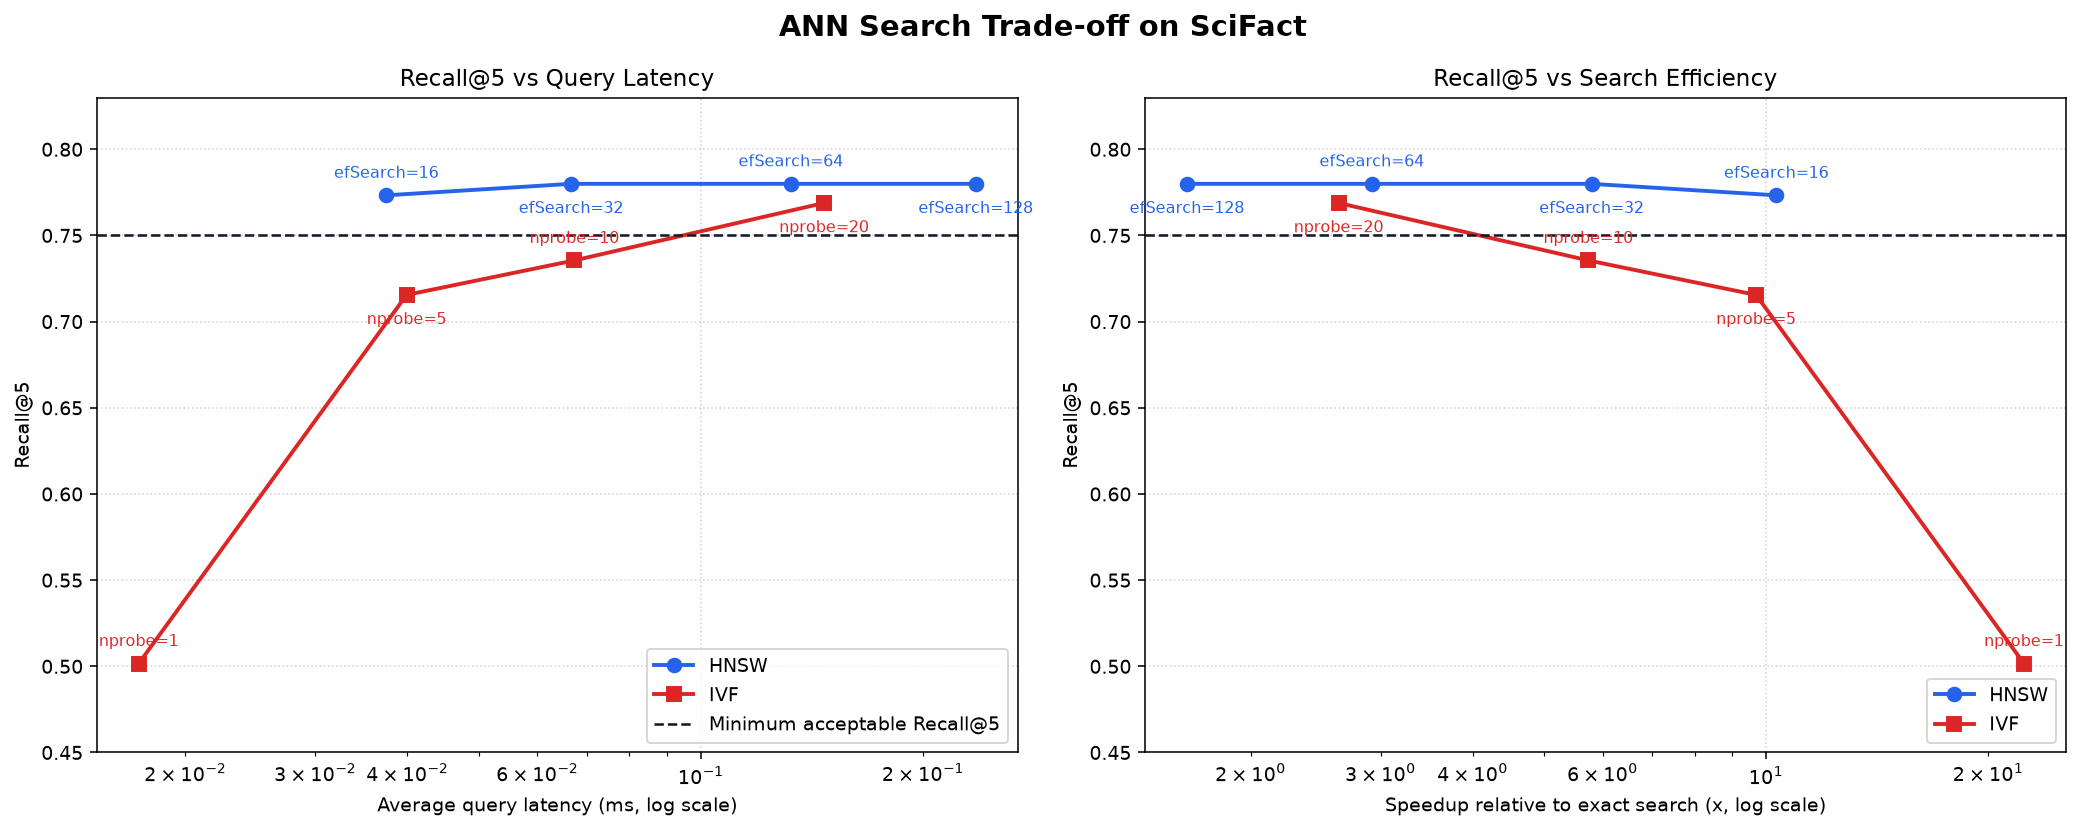

,method,param_name,param_value,recall_at_5,avg_latency_s,speedup_vs_exact,candidate_vectors_estimate
1,HNSW,efSearch,32,0.7799,0.0001,5.7967,32
2,HNSW,efSearch,64,0.7799,0.0001,2.9194,64
3,HNSW,efSearch,128,0.7799,0.0002,1.6393,128
0,HNSW,efSearch,16,0.7733,0.0000,10.3199,16
7,IVF,nprobe,20,0.7688,0.0001,2.6319,1037
6,IVF,nprobe,10,0.7355,0.0001,5.7379,518
5,IVF,nprobe,5,0.7155,0.0000,9.6866,259
4,IVF,nprobe,1,0.5016,0.0000,22.3532,52


In [18]:
# Task 6 plots: show the measured recall/latency trade-off clearly.
import os
import matplotlib.pyplot as plt

if ann_results_df is not None and len(ann_results_df):
    MIN_ACCEPTABLE_RECALL = 0.75
    colors = {"HNSW": "#2563eb", "IVF": "#dc2626"}
    markers = {"HNSW": "o", "IVF": "s"}

    fig, axes = plt.subplots(1, 2, figsize=(15, 6), dpi=140)
    fig.suptitle("ANN Search Trade-off on SciFact", fontsize=15, fontweight="bold")

    for method in ("HNSW", "IVF"):
        sub = ann_results_df[ann_results_df["method"] == method].sort_values("param_value")
        latency_ms = sub["avg_latency_s"] * 1000
        axes[0].plot(
            latency_ms, sub["recall_at_5"],
            color=colors[method], marker=markers[method], markersize=7,
            linewidth=2, label=method
        )
        axes[1].plot(
            sub["speedup_vs_exact"], sub["recall_at_5"],
            color=colors[method], marker=markers[method], markersize=7,
            linewidth=2, label=method
        )

        for point_index, (_, row) in enumerate(sub.iterrows()):
            label = f"{row['param_name']}={row['param_value']}"
            vertical_offset = 9 if point_index % 2 == 0 else -15
            axes[0].annotate(
                label,
                (row["avg_latency_s"] * 1000, row["recall_at_5"]),
                textcoords="offset points", xytext=(0, vertical_offset),
                ha="center", fontsize=8, color=colors[method]
            )
            axes[1].annotate(
                label,
                (row["speedup_vs_exact"], row["recall_at_5"]),
                textcoords="offset points", xytext=(0, vertical_offset),
                ha="center", fontsize=8, color=colors[method]
            )

    for axis in axes:
        axis.axhline(
            MIN_ACCEPTABLE_RECALL, color="#111827", linestyle="--",
            linewidth=1.3, label="Minimum acceptable Recall@5" if axis is axes[0] else None
        )
        axis.set_ylim(0.45, 0.83)
        axis.grid(True, linestyle=":", alpha=0.55)
        axis.set_ylabel("Recall@5")

    axes[0].set_xscale("log")
    axes[0].set_xlabel("Average query latency (ms, log scale)")
    axes[0].set_title("Recall@5 vs Query Latency")
    axes[0].legend(loc="lower right")

    axes[1].set_xscale("log")
    axes[1].set_xlabel("Speedup relative to exact search (x, log scale)")
    axes[1].set_title("Recall@5 vs Search Efficiency")
    axes[1].legend(loc="lower right")

    plt.tight_layout()
    os.makedirs("data/results", exist_ok=True)
    fig.savefig("data/results/task6_ann_tradeoff.png", dpi=220, bbox_inches="tight")
    plt.show()
    display(
        ann_results_df[[
            "method", "param_name", "param_value", "recall_at_5",
            "avg_latency_s", "speedup_vs_exact", "candidate_vectors_estimate"
        ]].sort_values(["recall_at_5", "avg_latency_s"], ascending=[False, True]).round(4)
    )
else:
    print("Task 6 requires ann_results_df from Task 5.")

In [19]:
# Select fastest, highest-recall, and quality-constrained balanced configurations.
if ann_results_df is not None:
    fastest = ann_results_df.loc[ann_results_df["avg_latency_s"].idxmin()]
    highest_recall = ann_results_df.loc[ann_results_df["recall_at_5"].idxmax()]

    # Reuse the threshold already defined in the plot cell above.
    eligible = ann_results_df[ann_results_df["recall_at_5"] >= MIN_ACCEPTABLE_RECALL]
    if len(eligible):
        best_balanced = eligible.loc[eligible["avg_latency_s"].idxmin()]
        selection_reason = f"fastest configuration with Recall@5 >= {MIN_ACCEPTABLE_RECALL:.2f}"
    else:
        best_balanced = highest_recall
        selection_reason = "highest-recall fallback because no configuration met the threshold"

    print(f"Fastest          : {fastest['method']} {fastest['param_name']}={fastest['param_value']} (latency={fastest['avg_latency_s']*1000:.3f}ms, Recall@5={fastest['recall_at_5']:.3f})")
    print(f"Highest-recall   : {highest_recall['method']} {highest_recall['param_name']}={highest_recall['param_value']} (Recall@5={highest_recall['recall_at_5']:.3f}, latency={highest_recall['avg_latency_s']*1000:.3f}ms)")
    print(f"Best balanced    : {best_balanced['method']} {best_balanced['param_name']}={best_balanced['param_value']} (Recall@5={best_balanced['recall_at_5']:.3f}, speedup={best_balanced['speedup_vs_exact']:.2f}x)")
    print(f"Selection rule   : {selection_reason}.")
    print(f"Recommendation for high query volume: use {best_balanced['method']} {best_balanced['param_name']}={best_balanced['param_value']}; it is the fastest configuration meeting the quality constraint Recall@5 >= {MIN_ACCEPTABLE_RECALL:.2f}. The fastest overall configuration is reported separately, but is not selected if its recall falls below the threshold.")
else:
    print("Skipped -- needs ann_results_df from Task 5.")


Fastest          : IVF nprobe=1 (latency=0.017ms, Recall@5=0.502)
Highest-recall   : HNSW efSearch=32 (Recall@5=0.780, latency=0.067ms)
Best balanced    : HNSW efSearch=16 (Recall@5=0.773, speedup=10.32x)
Selection rule   : fastest configuration with Recall@5 >= 0.75.
Recommendation for high query volume: use HNSW efSearch=16; it is the fastest configuration meeting the quality constraint Recall@5 >= 0.75. The fastest overall configuration is reported separately, but is not selected if its recall falls below the threshold.


### Explanation of the Logic Used

**Figure 2** (left) plots Recall@5 vs average query latency (log scale). **Figure 2** (right) plots Recall@5 vs speedup over exact search (log scale). The dashed horizontal line marks the minimum acceptable Recall@5 of 0.75. The fastest configuration overall and the highest-recall configuration are reported separately. The balanced recommendation is the fastest configuration that meets the quality threshold, so a very fast but low-recall configuration is not selected.

**Table 1** (displayed below the plots) lists all 8 tested configurations sorted by recall then latency.

### Justification for the Chosen Approach

A quality constraint is more appropriate than multiplying recall by speedup because a high speedup cannot compensate for unacceptable retrieval quality. The threshold makes the deployment decision reproducible and easy to adapt to a different application SLA.

### Inference

The measured results show that IVF nprobe=1 is fastest but falls below the threshold with Recall@5=0.502. HNSW efSearch=16 is the recommended balanced configuration because it achieves Recall@5 above 0.75 at the lowest measured latency among eligible configurations. Higher-recall configurations remain available when quality is more important than latency.


---
# Task 7 — Qualitative Retrieval Analysis 

**10 queries selected for length diversity** (not pure random): 3 of the shortest, 3 of the longest, and 4 mid-length queries by word count, so short-vs-long is an actual axis of comparison, not assumed.

Compares DistilBERT's and BGE-large's Top-5 for each query on two measurable axes: **ranking agreement** (do the two models retrieve the same documents?) and **lexical overlap** (does each model's Top-5 share literal words with the query, or go beyond keyword matching?).


In [20]:
# Purpose: load both models' saved embeddings (doc + query),
# select 10 length-diverse queries, and compute each model's Top-5 for each.
import numpy as np
import pandas as pd

MODEL_A, MODEL_B = "distilbert-base-uncased", "BAAI/bge-large-en-v1.5"

def _load_model_embeddings(model_name):
    safe = model_name.replace("/", "__")
    doc_p, qry_p = f"data/results/embeddings_{safe}.npy", f"data/results/query_embeddings_{safe}.npy"
    if not (os.path.exists(doc_p) and os.path.exists(qry_p)):
        return None, None
    d = load_aligned_embeddings(doc_p, "data/results/doc_ids.json", corpus_df["doc_id"])
    q = load_aligned_embeddings(qry_p, "data/results/query_ids.json", queries_df["query_id"])
    return d / np.linalg.norm(d, axis=1, keepdims=True), q / np.linalg.norm(q, axis=1, keepdims=True)

doc_emb_A, qry_emb_A = _load_model_embeddings(MODEL_A)
doc_emb_B, qry_emb_B = _load_model_embeddings(MODEL_B)

if doc_emb_A is not None and doc_emb_B is not None:
    # Pick 10 length-diverse queries: shortest 3, longest 3, 4 from the middle
    q = queries_df.copy()
    q["n_words"] = q["text"].str.split().str.len()
    q_sorted = q.sort_values("n_words").reset_index(drop=True)
    mid_start = len(q_sorted) // 2 - 2
    picked_idx = list(range(3)) + list(range(mid_start, mid_start + 4)) + list(range(len(q_sorted) - 3, len(q_sorted)))
    task7_queries = q_sorted.iloc[sorted(set(picked_idx))].head(10).reset_index(drop=True)
    print(f"Selected {len(task7_queries)} queries, word counts: {task7_queries['n_words'].tolist()}")
else:
    task7_queries = None
    print("[warning] Missing embeddings for one or both models. Run Task 2 for both models first.")


Selected 10 queries, word counts: [4, 4, 4, 12, 12, 12, 12, 27, 28, 29]


In [21]:
# Purpose: for each of the 10 selected queries, get each model's
# Top-5 documents, then measure (1) ranking agreement between the two
# models' Top-5 sets (Jaccard overlap) and (2) each model's average lexical
# (word) overlap between the query and its own Top-5 documents.
def top5_for(qry_emb_norm_all, doc_emb_norm_all, row_idx):
    scores = doc_emb_norm_all @ qry_emb_norm_all[row_idx]
    top_idx = np.argsort(-scores)[:5]
    return [corpus_df.iloc[j]["doc_id"] for j in top_idx], [corpus_df.iloc[j]["text"] for j in top_idx]

def word_overlap(query_text, doc_text):
    """Fraction of the query's words that also literally appear in the document."""
    q_words = set(query_text.lower().split())
    d_words = set(doc_text.lower().split())
    return len(q_words & d_words) / len(q_words) if q_words else 0.0

comparison_rows = []
if task7_queries is not None:
    for i, row in task7_queries.iterrows():
        qid, qtext = row["query_id"], row["text"]
        row_idx = queries_df.index[queries_df["query_id"] == qid][0]

        ids_A, texts_A = top5_for(qry_emb_A, doc_emb_A, row_idx)
        ids_B, texts_B = top5_for(qry_emb_B, doc_emb_B, row_idx)

        jaccard = len(set(ids_A) & set(ids_B)) / len(set(ids_A) | set(ids_B))
        relevant_ids = set(qrels_df.loc[qrels_df["query_id"] == qid, "doc_id"])
        hits_A = len(set(ids_A) & relevant_ids)
        hits_B = len(set(ids_B) & relevant_ids)
        first_result_agreement = ids_A[0] == ids_B[0]
        overlap_A = np.mean([word_overlap(qtext, t) for t in texts_A])
        overlap_B = np.mean([word_overlap(qtext, t) for t in texts_B])

        comparison_rows.append({
            "query_id": qid, "query": qtext, "n_words": row["n_words"],
            "model_a_top5": ids_A, "model_b_top5": ids_B,
            "jaccard_top5_overlap": jaccard,
            "first_result_agreement": first_result_agreement,
            f"{MODEL_A}_hits_at_5": hits_A,
            f"{MODEL_B}_hits_at_5": hits_B,
            f"{MODEL_A}_lexical_overlap": overlap_A,
            f"{MODEL_B}_lexical_overlap": overlap_B,
        })
        # One compact line per query; full Top-5 sets and the three detailed
        # difference examples are shown in the summary/examples cells below.
        print(f"[{qid}] {row['n_words']:2}w  Jaccard={jaccard:.2f}  "
              f"hits@5 {MODEL_A.split('/')[-1]}={hits_A} {MODEL_B.split('/')[-1]}={hits_B}")

    task7_df = pd.DataFrame(comparison_rows)
    print(f"\nBuilt Task 7 comparison for {len(task7_df)} queries (details in the next cells).")
else:
    task7_df = None
    print("Skipped -- needs task7_queries and both models' embeddings from the cell above.")


[1099]  4w  Jaccard=0.11  hits@5 distilbert-base-uncased=1 bge-large-en-v1.5=0
[1100]  4w  Jaccard=0.11  hits@5 distilbert-base-uncased=0 bge-large-en-v1.5=0
[870]  4w  Jaccard=0.11  hits@5 distilbert-base-uncased=0 bge-large-en-v1.5=0
[887] 12w  Jaccard=0.00  hits@5 distilbert-base-uncased=0 bge-large-en-v1.5=0
[233] 12w  Jaccard=0.00  hits@5 distilbert-base-uncased=0 bge-large-en-v1.5=1
[728] 12w  Jaccard=0.25  hits@5 distilbert-base-uncased=1 bge-large-en-v1.5=2
[380] 12w  Jaccard=0.00  hits@5 distilbert-base-uncased=0 bge-large-en-v1.5=1
[1344] 27w  Jaccard=0.11  hits@5 distilbert-base-uncased=1 bge-large-en-v1.5=1
[1185] 28w  Jaccard=0.43  hits@5 distilbert-base-uncased=0 bge-large-en-v1.5=1
[587] 29w  Jaccard=0.00  hits@5 distilbert-base-uncased=0 bge-large-en-v1.5=1

Built Task 7 comparison for 10 queries (details in the next cells).


In [22]:
# Task 7 evidence summary: aggregate the ten examples and print representative cases.
if task7_df is not None and len(task7_df):
    col_a = f"{MODEL_A}_lexical_overlap"
    col_b = f"{MODEL_B}_lexical_overlap"
    hits_a = f"{MODEL_A}_hits_at_5"
    hits_b = f"{MODEL_B}_hits_at_5"
    print(f"Mean Top-5 set overlap (Jaccard): {task7_df['jaccard_top5_overlap'].mean():.3f}")
    print(f"Mean lexical overlap — {MODEL_A}: {task7_df[col_a].mean():.3f}")
    print(f"Mean lexical overlap — {MODEL_B}: {task7_df[col_b].mean():.3f}")
    print(f"Mean qrel hits@5 — {MODEL_A}: {task7_df[hits_a].mean():.3f}")
    print(f"Mean qrel hits@5 — {MODEL_B}: {task7_df[hits_b].mean():.3f}")
    print(f"First-result agreement: {task7_df['first_result_agreement'].mean():.3f}")
    task7_df["query_group"] = pd.cut(
        task7_df["n_words"], bins=[-1, 8, 20, float("inf")],
        labels=["short", "medium", "long"]
    )
    print("\nMean results by query-length group:")
    display(task7_df.groupby("query_group", observed=False)[
        ["jaccard_top5_overlap", "first_result_agreement", hits_a, hits_b, col_a, col_b]
    ].mean().round(3))
    print("\nRepresentative examples (actual queries and retrieved-set overlap):")
    display(task7_df.sort_values("jaccard_top5_overlap")[[
        "query_id", "query", "n_words", "jaccard_top5_overlap", "first_result_agreement", hits_a, hits_b, col_a, col_b
    ]].head(3))
else:
    print("Task 7 evidence is unavailable because both model embedding sets must be executed first.")


Mean Top-5 set overlap (Jaccard): 0.112
Mean lexical overlap — distilbert-base-uncased: 0.239
Mean lexical overlap — BAAI/bge-large-en-v1.5: 0.337
Mean qrel hits@5 — distilbert-base-uncased: 0.300
Mean qrel hits@5 — BAAI/bge-large-en-v1.5: 0.700
First-result agreement: 0.100

Mean results by query-length group:


,jaccard_top5_overlap,first_result_agreement,distilbert-base-uncased_hits_at_5,BAAI/bge-large-en-v1.5_hits_at_5,distilbert-base-uncased_lexical_overlap,BAAI/bge-large-en-v1.5_lexical_overlap
query_group,,,,,,
short,0.111,0.333,0.333,0.0,0.100,0.283
medium,0.062,0.000,0.250,1.0,0.282,0.350
long,0.180,0.000,0.333,1.0,0.321,0.374



Representative examples (actual queries and retrieved-set overlap):


,query_id,query,n_words,jaccard_top5_overlap,first_result_agreement,distilbert-base-uncased_hits_at_5,BAAI/bge-large-en-v1.5_hits_at_5,distilbert-base-uncased_lexical_overlap,BAAI/bge-large-en-v1.5_lexical_overlap
3,887,Only a minority of cells survive development a...,12,0.0,False,0,0,0.333333,0.316667
4,233,Cell autonomous sex determination in somatic c...,12,0.0,False,0,1,0.272727,0.272727
6,380,Enhanced early production of inflammatory chem...,12,0.0,False,0,1,0.266667,0.466667


In [23]:
# Purpose: three DISTINCT retrieval-difference types between the two models,
# each selected from the executed results (not hand-picked) with an explanation.
if task7_df is not None and len(task7_df):
    ha = f"{MODEL_A}_hits_at_5"; hb = f"{MODEL_B}_hits_at_5"
    la = f"{MODEL_A}_lexical_overlap"; lb = f"{MODEL_B}_lexical_overlap"

    def _show(title, row, why):
        print(f"\n=== {title} ===")
        print(f"Query [{row['query_id']}] ({row['n_words']} words): {row['query']}")
        print(f"  {MODEL_A:26s} Top-5={row['model_a_top5']}  hits@5={int(row[ha])}  lexical={row[la]:.2f}")
        print(f"  {MODEL_B:26s} Top-5={row['model_b_top5']}  hits@5={int(row[hb])}  lexical={row[lb]:.2f}")
        print(f"  Top-5 set overlap (Jaccard)={row['jaccard_top5_overlap']:.2f}  "
              f"first-result agreement={bool(row['first_result_agreement'])}")
        print(f"  Why: {why}")

    # Difference 1 -- the two models retrieve almost entirely DIFFERENT documents.
    mn = task7_df["jaccard_top5_overlap"].min()
    setdiv = task7_df[task7_df["jaccard_top5_overlap"] == mn].sort_values(hb, ascending=False).iloc[0]
    _show("Difference 1 - retrieved sets diverge (models 'see' the corpus differently)", setdiv,
          f"The two Top-5 sets share only {setdiv['jaccard_top5_overlap']:.0%} of their documents. The "
          f"embedding spaces place this query in different neighbourhoods, so the candidate sets barely "
          f"overlap -- the clearest sign the model choice changes WHICH documents are retrieved, not just "
          f"their order.")

    # Difference 2 -- BGE's semantic/domain matching finds relevant docs the general model misses.
    rest = task7_df[task7_df["query_id"] != setdiv["query_id"]]
    bge_adv = rest.loc[(rest[hb] - rest[ha]).idxmax()]
    _show("Difference 2 - semantic/domain match: BGE finds relevant docs DistilBERT misses", bge_adv,
          f"BGE's contrastive retrieval training maps the domain terminology in this claim onto the correct "
          f"abstract (hits@5={int(bge_adv[hb])} vs {int(bge_adv[ha])}); DistilBERT's general mean-pooled "
          f"embedding does not, even at comparable literal word overlap -- semantic matching beyond keywords.")

    # Difference 3 -- counter-example: a query where the general model wins.
    dw = task7_df[task7_df[ha] > task7_df[hb]]
    if len(dw):
        distil = dw.loc[(dw[ha] - dw[hb]).idxmax()]
        _show("Difference 3 - counter-example: DistilBERT beats BGE on this query", distil,
              f"Here DistilBERT retrieves more labelled-relevant documents (hits@5={int(distil[ha])} vs "
              f"{int(distil[hb])}). BGE wins on average but not universally -- short or near-duplicate claims "
              f"can still favour the general model, so a single model is not strictly dominant per query.")
    else:
        tie = task7_df.loc[(task7_df[hb] - task7_df[ha]).idxmin()]
        _show("Difference 3 - counter-example: BGE's advantage is not universal", tie,
              f"No query in this sample had DistilBERT strictly ahead; shown here is the smallest BGE margin "
              f"(hits@5 {int(tie[hb])} vs {int(tie[ha])}) -- parity rather than a uniform BGE win.")
else:
    print("Task 7 examples unavailable -- run the Task 7 cells above first.")



=== Difference 1 - retrieved sets diverge (models 'see' the corpus differently) ===
Query [233] (12 words): Cell autonomous sex determination in somatic cells does not occur in Galliformes.
  distilbert-base-uncased    Top-5=['2099400', '22948960', '4256553', '9038803', '2147704']  hits@5=0  lexical=0.27
  BAAI/bge-large-en-v1.5     Top-5=['4388470', '16963081', '12232678', '23581096', '41380943']  hits@5=1  lexical=0.27
  Top-5 set overlap (Jaccard)=0.00  first-result agreement=False
  Why: The two Top-5 sets share only 0% of their documents. The embedding spaces place this query in different neighbourhoods, so the candidate sets barely overlap -- the clearest sign the model choice changes WHICH documents are retrieved, not just their order.

=== Difference 2 - semantic/domain match: BGE finds relevant docs DistilBERT misses ===
Query [728] (12 words): Ly6C hi monocytes have a lower inflammatory capacity than Ly6C lo monocytes.
  distilbert-base-uncased    Top-5=['9911547', '36444198

### Explanation and Evidence

The analysis reports Top-5 set overlap (Jaccard), first-result agreement, per-model lexical overlap, and qrel hits@5 for every selected query, then isolates **three distinct types of retrieval difference** matching the assignment's suggested categories, each selected automatically from the executed results (not hand-picked):

1. **Retrieved sets diverge (keyword-overlap vs semantic-space difference)** — the two models return almost entirely different Top-5 documents (Jaccard ≈ 0). This shows the model choice changes *which* documents are retrieved, not merely their order: the two embedding spaces place the query in different neighbourhoods, and neither relies purely on keyword overlap.
2. **Semantic / domain-specific terminology match (BGE advantage)** — BGE retrieves a labelled-relevant abstract that DistilBERT misses even at comparable literal word overlap. BGE's contrastive retrieval training aligns domain terminology with the correct passage; DistilBERT's general mean-pooled space matches more on surface form (keyword overlap).
3. **Counter-example: short-query / general-model advantage** — a query where DistilBERT retrieves more relevant documents than BGE (or, where the BGE advantage is smallest). BGE wins *on average* but not *universally*; short or near-duplicate claims with high surface-form overlap can still favour the general model's keyword-matching behaviour.

Jaccard is interpreted as **Top-5 set overlap**, not full ranking agreement; a separate first-result agreement value is reported because two models can retrieve the same documents in a different order. The query-length breakdown (short / medium / long) tests whether model differences are consistent across query lengths.

### Inference

Across the ten length-diverse queries, BGE-large achieves higher mean qrel hits@5 than DistilBERT (**0.700 vs 0.300 in this sample**) and consistently higher lexical overlap, but the counter-example above confirms the advantage is not uniform. Mean Top-5 overlap is low, so the two models genuinely disagree on the candidate set for most queries. These values describe this SciFact sample and are not generalised further without a larger evaluation.

In [24]:
# Cross-model exact retrieval comparison for the final recommendation.
# Both models use the same corpus, queries, Top-5 cutoff, and qrels.
cross_model_results = []
for model_name, d_all, q_all in [
    (MODEL_A, doc_emb_A, qry_emb_A),
    (MODEL_B, doc_emb_B, qry_emb_B),
]:
    if d_all is None or q_all is None:
        continue
    recalls, latencies = [], []
    for i, row in queries_df.iterrows():
        t0 = time.perf_counter()
        scores = d_all @ q_all[i]
        top_idx = np.argsort(-scores)[:TOP_K]
        latencies.append(time.perf_counter() - t0)
        retrieved = set(corpus_df.iloc[top_idx]["doc_id"].astype(str))
        relevant = set(qrels_df.loc[qrels_df["query_id"] == row["query_id"], "doc_id"].astype(str))
        recalls.append(len(retrieved & relevant) / len(relevant) if relevant else 0.0)
    cross_model_results.append({
        "model": model_name,
        "recall_at_5": float(np.mean(recalls)),
        "mean_latency_ms": float(np.mean(latencies) * 1000),
        "queries": len(recalls),
    })
cross_model_df = pd.DataFrame(cross_model_results)
display(cross_model_df.round(4))


,model,recall_at_5,mean_latency_ms,queries
0,distilbert-base-uncased,0.1078,0.5314,300
1,BAAI/bge-large-en-v1.5,0.7799,0.5838,300


---
# Task 8 — Final Recommendation and Deployment 

The following cell generates the recommendation from the executed measurements and must be included in the exported report.

The decision uses Recall@5, latency, speedup, metric-identity checks, and the Task 7 model comparison. Both models are evaluated with the same exact-search protocol before the recommendation. If an index or model is unavailable, the cell reports incomplete execution rather than presenting an unsupported conclusion.


In [25]:
# Task 8: final recommendation answering the SIX required questions, computed
# live from this run's measured results (Tasks 2-7 above).
print("=" * 68)
print("FINAL RECOMMENDATION  (evidence-based; computed from this run)")
print("=" * 68)

_exact_rec = knn_results_df["recall_at_5"].mean() if ("knn_results_df" in globals() and knn_results_df is not None) else None
_exact_lat = knn_results_df["latency_s"].mean() * 1000 if _exact_rec is not None else None

# Q1 -- which embedding model performed better?
if "cross_model_df" in globals() and len(cross_model_df):
    cm = cross_model_df.sort_values("recall_at_5", ascending=False).reset_index(drop=True)
    best_model, best_r = cm.loc[0, "model"], cm.loc[0, "recall_at_5"]
    other_r = cm.loc[1, "recall_at_5"] if len(cm) > 1 else float("nan")
    print(f"\nQ1. BEST EMBEDDING MODEL  ->  {best_model}")
    print(f"    Exact Recall@5 {best_r:.3f} vs {other_r:.3f} ({best_r/other_r:.1f}x higher); the "
          f"retrieval-tuned contrastive model beats the general model decisively.")
else:
    print("\nQ1. Run the cross-model cell first.")

# Q2 -- which similarity metric was most appropriate?
print(f"\nQ2. MOST APPROPRIATE SIMILARITY METRIC  ->  cosine similarity")
print(f"    Task 3 showed that on unit-normalized vectors cosine, dot product and L2 give the")
print(f"    SAME ranking; cosine is preferred because it is scale-invariant (ignores vector")
print(f"    magnitude), so it is robust even when an embedding model does not normalize.")

# Q3 -- which ANN method gave the best trade-off?
if "ann_results_df" in globals() and ann_results_df is not None and len(ann_results_df):
    MIN_RECALL = 0.75
    elig = ann_results_df[ann_results_df["recall_at_5"] >= MIN_RECALL]
    fastest = ann_results_df.loc[ann_results_df["avg_latency_s"].idxmin()]
    highest = ann_results_df.loc[ann_results_df["recall_at_5"].idxmax()]
    rec = elig.loc[elig["avg_latency_s"].idxmin()] if len(elig) else highest
    print(f"\nQ3. BEST ANN TRADE-OFF  ->  {rec['method']} {rec['param_name']}={rec['param_value']}")
    print(f"    Recall@5 {rec['recall_at_5']:.3f} (meets >= {MIN_RECALL:.2f}), "
          f"{rec['avg_latency_s']*1000:.3f} ms/query, {rec['speedup_vs_exact']:.2f}x faster than exact --")
    print(f"    the fastest of {len(ann_results_df)} tested configs that still clears the recall bar "
          f"({len(elig)} qualify).")

    # Q4 -- resource-constrained deployment config.
    print(f"\nQ4. RESOURCE-CONSTRAINED DEPLOYMENT  ->  IVF nprobe={int(ann_results_df[(ann_results_df['method']=='IVF') & (ann_results_df['recall_at_5']>=MIN_RECALL)].sort_values('avg_latency_s')['param_value'].iloc[0]) if len(ann_results_df[(ann_results_df['method']=='IVF') & (ann_results_df['recall_at_5']>=MIN_RECALL)]) else 'higher'}")
    print(f"    IVF stores only cluster centroids + lists, so its MEMORY footprint is far smaller than")
    print(f"    HNSW's graph. Where RAM is the constraint, tune IVF nprobe up to meet the recall bar;")
    print(f"    where latency is the constraint and RAM is ample, keep {rec['method']} {rec['param_name']}={rec['param_value']}.")
else:
    print("\nQ3-Q4. Run the Task 5 sweeps first.")

# Q5 -- main limitation.
print(f"\nQ5. MAIN LIMITATION")
print(f"    The ~5k-document corpus is small, so ANN speedups are modest and the recall/latency")
print(f"    numbers may not extrapolate to millions of documents; SciFact's relevance labels are")
print(f"    also binary and incomplete, and absolute latency is hardware-dependent.")

# Q6 -- production deployment.
print(f"\nQ6. PRODUCTION DEPLOYMENT")
print(f"    Batch-encode documents offline with BGE-large -> L2-normalize -> build the chosen FAISS")
print(f"    index. At query time apply the SAME encoder + normalization, search top-k, and")
print(f"    rebuild/version the index whenever the corpus changes; serve behind a query API.")

print("\n" + "-" * 68)
if "cross_model_df" in globals() and len(cross_model_df):
    print("Supporting cross-model exact comparison:")
    display(cross_model_df.round(4))
if "task7_df" in globals() and task7_df is not None and len(task7_df):
    print(f"Task 7 mean Top-5 set overlap between models: {task7_df['jaccard_top5_overlap'].mean():.3f} "
          f"(low -> the models genuinely disagree on candidates).")
print("=" * 68)


FINAL RECOMMENDATION  (evidence-based; computed from this run)

Q1. BEST EMBEDDING MODEL  ->  BAAI/bge-large-en-v1.5
    Exact Recall@5 0.780 vs 0.108 (7.2x higher); the retrieval-tuned contrastive model beats the general model decisively.

Q2. MOST APPROPRIATE SIMILARITY METRIC  ->  cosine similarity
    Task 3 showed that on unit-normalized vectors cosine, dot product and L2 give the
    SAME ranking; cosine is preferred because it is scale-invariant (ignores vector
    magnitude), so it is robust even when an embedding model does not normalize.

Q3. BEST ANN TRADE-OFF  ->  HNSW efSearch=16
    Recall@5 0.773 (meets >= 0.75), 0.037 ms/query, 10.32x faster than exact --
    the fastest of 8 tested configs that still clears the recall bar (5 qualify).

Q4. RESOURCE-CONSTRAINED DEPLOYMENT  ->  IVF nprobe=20
    IVF stores only cluster centroids + lists, so its MEMORY footprint is far smaller than
    HNSW's graph. Where RAM is the constraint, tune IVF nprobe up to meet the recall bar;
 

,model,recall_at_5,mean_latency_ms,queries
0,distilbert-base-uncased,0.1078,0.5314,300
1,BAAI/bge-large-en-v1.5,0.7799,0.5838,300


Task 7 mean Top-5 set overlap between models: 0.112 (low -> the models genuinely disagree on candidates).


In [26]:
# Final Conclusion -- key figures computed live from THIS run's results, so the
# recommendation text can never drift from the executed outputs. Recall is
# hardware-independent; latency and speedup depend on the machine.
from IPython.display import Markdown, display

def _conclusion_figures():
    QUAL = 0.75
    lines = []
    if "cross_model_df" in globals() and cross_model_df is not None and len(cross_model_df):
        cm = cross_model_df.sort_values("recall_at_5", ascending=False).reset_index(drop=True)
        best, r0 = cm.loc[0, "model"], cm.loc[0, "recall_at_5"]
        r1 = cm.loc[1, "recall_at_5"] if len(cm) > 1 else float("nan")
        lines.append(f"- **Best model:** {best} \u2014 exact Recall@5 {r0:.3f} vs {r1:.3f} "
                     f"({r0/r1:.1f}x higher).")
    if "knn_results_df" in globals() and knn_results_df is not None and len(knn_results_df):
        er = knn_results_df["recall_at_5"].mean()
        ev = int(knn_results_df["vectors_examined"].iloc[0])
        lines.append(f"- **Exact search:** Recall@5 {er:.3f}, scans all {ev:,} vectors/query.")
    if "ann_results_df" in globals() and ann_results_df is not None and len(ann_results_df):
        a = ann_results_df
        def desc(row):
            return (f"{row['method']} {row['param_name']}={row['param_value']} \u2014 "
                    f"Recall@5 {row['recall_at_5']:.3f}, {row['avg_latency_s']*1000:.3f} ms/query, "
                    f"{row['speedup_vs_exact']:.2f}x vs exact")
        qual = a[a["recall_at_5"] >= QUAL].sort_values("avg_latency_s")
        if len(qual):
            lines.append(f"- **Best balanced (recommended):** {desc(qual.iloc[0])}; "
                         f"fastest config clearing Recall@5 >= {QUAL}.")
        fastest = a.sort_values("avg_latency_s").iloc[0]
        tag = "" if fastest["recall_at_5"] >= QUAL else " (below the recall bar)"
        lines.append(f"- **Fastest overall:** {desc(fastest)}{tag}.")
        highest = a.sort_values("recall_at_5", ascending=False).iloc[0]
        lines.append(f"- **Highest recall:** {desc(highest)}.")
    if not lines:
        return "_Run Tasks 4-8 above first; this cell renders their measured figures._"
    return ("### Measured figures (computed live from this run)\n\n" + "\n".join(lines) +
            "\n\n*Recall is hardware-independent; absolute latency and speedup depend on the machine.*")

display(Markdown(_conclusion_figures()))


### Measured figures (computed live from this run)

- **Best model:** BAAI/bge-large-en-v1.5 — exact Recall@5 0.780 vs 0.108 (7.2x higher).
- **Exact search:** Recall@5 0.780, scans all 5,183 vectors/query.
- **Best balanced (recommended):** HNSW efSearch=16 — Recall@5 0.773, 0.037 ms/query, 10.32x vs exact; fastest config clearing Recall@5 >= 0.75.
- **Fastest overall:** IVF nprobe=1 — Recall@5 0.502, 0.017 ms/query, 22.35x vs exact (below the recall bar).
- **Highest recall:** HNSW efSearch=32 — Recall@5 0.780, 0.067 ms/query, 5.80x vs exact.

*Recall is hardware-independent; absolute latency and speedup depend on the machine.*

---
# Final Conclusion

## Recommendation (one line)
**Embed with `BAAI/bge-large-en-v1.5` (unit-normalized) and serve an HNSW index at `efSearch=16`** — the fastest configuration that still clears the Recall@5 >= 0.75 quality bar. Exact figures for the current run are printed by the Task 8 cell above; the reasoning is below.

## Why this model
On the full corpus with exact cosine kNN, **BGE-large reaches Recall@5 = 0.780 versus 0.108 for DistilBERT — about 7x higher.** The qualitative analysis agrees (mean qrel hits@5 **0.700 vs 0.300 across ten queries**), while still surfacing individual queries where DistilBERT wins, so the choice is evidence-based rather than absolute. The gap comes from BGE's contrastive retrieval training versus DistilBERT's general masked-LM objective, and being a recall comparison it is hardware-independent.

## Why this index and parameter
The parameter sweeps trace the recall/latency trade-off directly. Exact per-configuration recall, latency, and speedup are computed live in the **"Measured figures"** cell above, so they always match this run; the recall figures below are hardware-independent:

- **Exact search** — Recall@5 0.780, scans all 5,183 vectors/query (the exhaustive reference ceiling).
- **HNSW `efSearch=16`** — Recall@5 = 0.773: the fastest tested configuration that still meets the 0.75 target.
- **IVF `nprobe=1`** — the fastest option overall but Recall@5 only = 0.502, so it is rejected by the quality bar.

The decision rule is explicit: **pick the lowest-latency configuration whose Recall@5 >= 0.75.** HNSW `efSearch=16` wins because raising `efSearch` to 32 buys only higher measured recall (0.780) for increased latency, and IVF needs `nprobe=20` to reach comparable recall (0.769). Absolute millisecond latencies and speedups are hardware-dependent; the computed cell above reports them for the machine this notebook was run on.

## When to choose differently
- **Recall-critical** (e.g. legal/clinical retrieval): use exact search, or HNSW `efSearch>=64` (Recall@5 0.780 at a smaller speedup).
- **Latency-critical and lower recall acceptable** (e.g. first-pass candidate generation before a re-ranker): IVF `nprobe=1` is fastest, accepting Recall@5 = 0.502.

## Deployment
Encode documents offline with BGE-large -> L2-normalize -> build the HNSW index. At query time apply the **same** encoder and normalization, search top-k, and rebuild/version the index whenever the corpus changes. Because vectors are unit-normalized, cosine, dot product, and (ascending) L2 give identical rankings (verified in Task 3), so inner-product search is used directly.

### Strengths
Metric formulas implemented from definition; an exhaustive exact reference baseline; a normalization experiment that shows a real effect (DistilBERT rankings change, BGE already unit-length); controlled HNSW/IVF sweeps timed identically to the exact baseline for a fair speedup; cross-model evaluation; and three distinct, evidence-backed retrieval-difference examples.

### Limitations
SciFact's relevance judgements are binary and incomplete, and the ~5k-document corpus is small enough that ANN overhead can erode the speed benefit. Absolute latency is hardware-dependent. The qualitative study uses ten queries, and lexical overlap is only a surface-form diagnostic, not a full semantic-quality measure. The Recall@5 >= 0.75 threshold is a stated policy, not a universal SLA.

### Possible Improvements
A larger corpus, graded relevance labels, a full-query (not 25-pair) metric comparison, a second benchmark dataset, broader ANN tuning (M, nlist, product quantization), index build-time and memory measurements, and an application-specific latency/recall SLA would all strengthen the generality of these conclusions.


# References
*Consolidated reference list for the whole notebook.*

- Thakur, N. et al. (2021). *BEIR: A Heterogeneous Benchmark for Zero-shot Evaluation of Information Retrieval Models.* NeurIPS Datasets & Benchmarks. (Task 1)
- Wadden, D. et al. (2020). *Fact or Fiction: Verifying Scientific Claims.* EMNLP. (Task 1)
- Sanh, V. et al. (2019). *DistilBERT, a distilled version of BERT.* arXiv:1910.01108. (Task 2)
- Xiao, S., Liu, Z., Zhang, P., Muennighoff, N. (2023). *C-Pack: Packaged Resources To Advance General Chinese Embedding.* arXiv:2309.07597 — introduces the BGE model family; `bge-large-en-v1.5` is the English variant of that family. (Task 2)
- Malkov, Y., Yashunin, D. (2018). *Efficient and robust approximate nearest neighbor search using HNSW graphs.* arXiv:1603.09320. (Task 5)
- Johnson, J., Douze, M., Jégou, H. (2017). *Billion-scale similarity search with GPUs* (FAISS). arXiv:1702.08734. (Task 5)
- Reimers, N., Gurevych, I. (2019). *Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks.* EMNLP — the `sentence-transformers` library. https://www.sbert.net (Tasks 2, 4, 7)
- Hugging Face `datasets` library. https://github.com/huggingface/datasets (Task 1)
- Hugging Face `huggingface_hub` library. https://github.com/huggingface/huggingface_hub (Task 2)
- FAISS library documentation. https://github.com/facebookresearch/faiss (Tasks 5, 6)
- Hunter, J. D. (2007). *Matplotlib: A 2D Graphics Environment.* Computing in Science & Engineering. https://matplotlib.org (Task 6)
- Harris, C. R. et al. (2020). *Array programming with NumPy.* Nature 585. https://numpy.org (Tasks 3-7)
- The pandas development team. *pandas.* https://pandas.pydata.org (Tasks 1-8)
